###1. IMPORT MODULES FOR DATA ANALYSIS

In [ ]:
# Core Data Processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Machine Learning - Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Statistical Analysis
from scipy import stats
from scipy.stats import skew, kurtosis

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

###2. DATA ANALYSIS

##2.1. LOAD THE DATASET

In [ ]:
print("\n" + "-"*80)
print("2.1. LOAD THE DATASET")
print("-"*80)

# Load the Ames Housing dataset
df_original = pd.read_csv('AmesHousing.csv')

print(f"\n✓ Dataset loaded successfully!")
print(f"  • Dataset shape: {df_original.shape[0]} rows × {df_original.shape[1]} columns")
print(f"  • Memory usage: {df_original.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df_original.head())


--------------------------------------------------------------------------------
2.1. LOAD THE DATASET
--------------------------------------------------------------------------------

✓ Dataset loaded successfully!
  • Dataset shape: 2930 rows × 82 columns
  • Memory usage: 6.92 MB

First 5 rows of the dataset:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv        

##2.2. SCANNING / INSPECTION

In [ ]:
print("\n" + "-"*80)
print("2.2. SCANNING / INSPECTION")
print("-"*80)

# Basic information
print("\n--- Dataset Information ---")
print(df_original.info())

print("\n--- Statistical Summary ---")
print(df_original.describe())

# Identify feature types
numeric_features = df_original.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_original.select_dtypes(include=['object']).columns.tolist()

print(f"\n--- Feature Type Distribution ---")
print(f"Total features: {len(df_original.columns)}")
print(f"  • Numeric features: {len(numeric_features)}")
print(f"  • Categorical features: {len(categorical_features)}")
print(f"  • Target variable: SalePrice")

# Check target variable
print(f"\n--- Target Variable (SalePrice) Statistics ---")
print(df_original['SalePrice'].describe())
print(f"\nSkewness: {df_original['SalePrice'].skew():.4f}")
print(f"Kurtosis: {df_original['SalePrice'].kurtosis():.4f}")


--------------------------------------------------------------------------------
2.2. SCANNING / INSPECTION
--------------------------------------------------------------------------------

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non

##2.3. DETECTING AND QUANTIFYING MISSING VALUES

In [ ]:
print("\n" + "-"*80)
print("2.3. DETECTING AND QUANTIFYING MISSING VALUES")
print("-"*80)

# Calculate missing values
missing_values = df_original.isnull().sum()
missing_percent = (missing_values / len(df_original)) * 100

# Create missing values dataframe
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Percentage': missing_percent.values
})

# Filter only columns with missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(f"\n--- Missing Values Summary ---")
print(f"Total columns with missing values: {len(missing_df)}")
print(f"Total missing values: {missing_df['Missing_Count'].sum()}")
print(f"\nTop 15 columns with missing values:")
print(missing_df.head(15).to_string(index=False))


--------------------------------------------------------------------------------
2.3. DETECTING AND QUANTIFYING MISSING VALUES
--------------------------------------------------------------------------------

--- Missing Values Summary ---
Total columns with missing values: 27
Total missing values: 15749

Top 15 columns with missing values:
        Column  Missing_Count  Percentage
       Pool QC           2917   99.556314
  Misc Feature           2824   96.382253
         Alley           2732   93.242321
         Fence           2358   80.477816
  Mas Vnr Type           1775   60.580205
  Fireplace Qu           1422   48.532423
  Lot Frontage            490   16.723549
   Garage Qual            159    5.426621
   Garage Cond            159    5.426621
 Garage Yr Blt            159    5.426621
 Garage Finish            159    5.426621
   Garage Type            157    5.358362
 Bsmt Exposure             83    2.832765
BsmtFin Type 2             81    2.764505
     Bsmt Cond            

##2.4. VISUALIZING THE MISSING VALUES


--------------------------------------------------------------------------------
2.4. VISUALIZING THE MISSING VALUES
--------------------------------------------------------------------------------


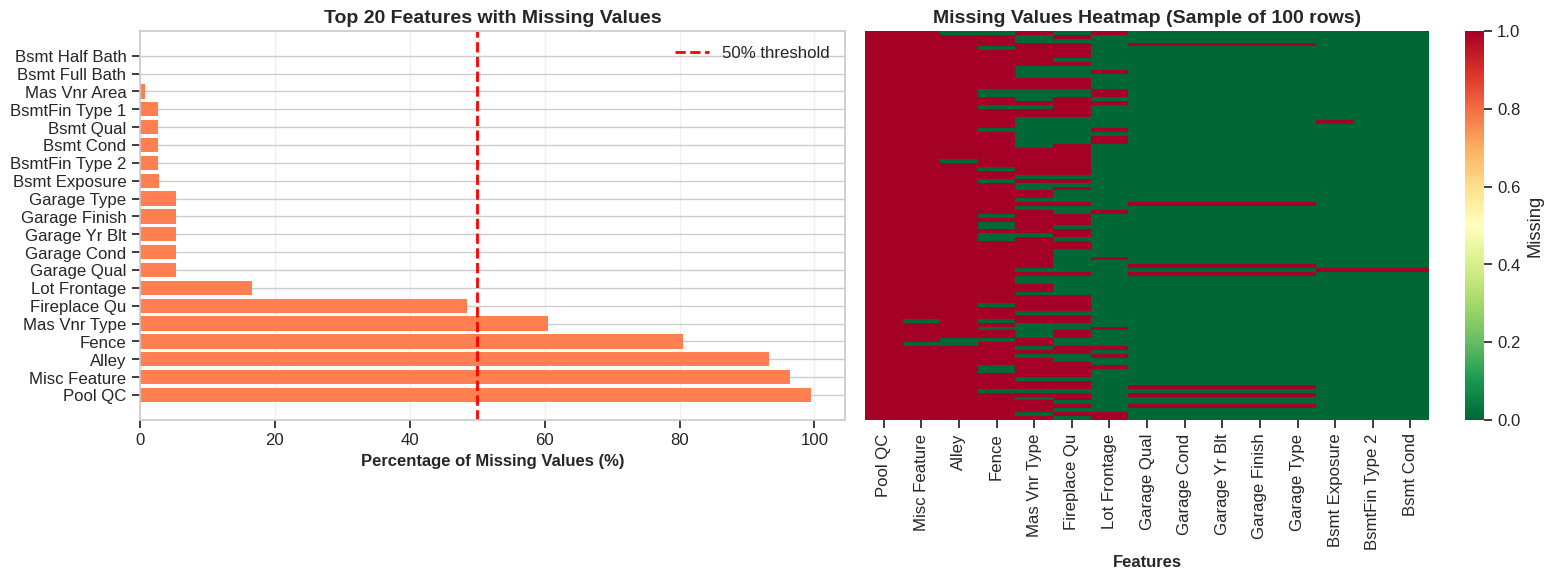


✓ Visualization saved: 01_missing_values_analysis.png


In [ ]:
print("\n" + "-"*80)
print("2.4. VISUALIZING THE MISSING VALUES")
print("-"*80)

if len(missing_df) > 0:
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Bar chart of missing values percentage
    ax1 = axes[0]
    top_missing = missing_df.head(20)
    ax1.barh(range(len(top_missing)), top_missing['Percentage'], color='coral')
    ax1.set_yticks(range(len(top_missing)))
    ax1.set_yticklabels(top_missing['Column'])
    ax1.set_xlabel('Percentage of Missing Values (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Top 20 Features with Missing Values', fontsize=14, fontweight='bold')
    ax1.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)

    # Plot 2: Missing values heatmap (sample)
    ax2 = axes[1]
    # Select columns with missing values for visualization
    missing_cols = missing_df.head(15)['Column'].tolist()
    sample_df = df_original[missing_cols].sample(min(100, len(df_original)), random_state=42)
    sns.heatmap(sample_df.isnull(), cbar=True, cmap='RdYlGn_r', ax=ax2,
                yticklabels=False, cbar_kws={'label': 'Missing'})
    ax2.set_title('Missing Values Heatmap (Sample of 100 rows)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Features', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('01_missing_values_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Visualization saved: 01_missing_values_analysis.png")
else:
    print("\n✓ No missing values detected in the dataset!")



##2.5. DEALING WITH MISSING VALUES

In [ ]:
print("\n" + "-"*80)
print("2.5. DEALING WITH MISSING VALUES")
print("-"*80)

# Create a copy for processing
df = df_original.copy()

print("\n--- Strategy 1: Drop columns with >50% missing values ---")
high_missing_threshold = 50
high_missing_cols = missing_df[missing_df['Percentage'] > high_missing_threshold]['Column'].tolist()
print(f"Columns to drop (>{high_missing_threshold}% missing): {len(high_missing_cols)}")
for col in high_missing_cols:
    print(f"  • {col}: {missing_df[missing_df['Column']==col]['Percentage'].values[0]:.1f}% missing")

df = df.drop(columns=high_missing_cols)

print("\n--- Strategy 2: Fill numeric missing values with median ---")
numeric_cols_with_missing = [col for col in numeric_features
                              if col in df.columns and df[col].isnull().sum() > 0]
print(f"Numeric columns to fill: {len(numeric_cols_with_missing)}")
filled_numeric = 0
for col in numeric_cols_with_missing:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
    filled_numeric += 1
print(f"  ✓ Filled {filled_numeric} numeric columns with median")

print("\n--- Strategy 3: Fill categorical missing values with mode ---")
categorical_cols_with_missing = [col for col in categorical_features
                                  if col in df.columns and df[col].isnull().sum() > 0]
print(f"Categorical columns to fill: {len(categorical_cols_with_missing)}")
filled_categorical = 0
for col in categorical_cols_with_missing:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)
    filled_categorical += 1
print(f"  ✓ Filled {filled_categorical} categorical columns with mode")

# Verify no missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"\n--- Verification ---")
print(f"Total missing values remaining: {remaining_missing}")
if remaining_missing == 0:
    print("✓ All missing values handled successfully!")
else:
    print(f"⚠ Warning: {remaining_missing} missing values still remain")

print(f"\nDataset shape after handling missing values: {df.shape}")




--------------------------------------------------------------------------------
2.5. DEALING WITH MISSING VALUES
--------------------------------------------------------------------------------

--- Strategy 1: Drop columns with >50% missing values ---
Columns to drop (>50% missing): 5
  • Pool QC: 99.6% missing
  • Misc Feature: 96.4% missing
  • Alley: 93.2% missing
  • Fence: 80.5% missing
  • Mas Vnr Type: 60.6% missing

--- Strategy 2: Fill numeric missing values with median ---
Numeric columns to fill: 11
  ✓ Filled 11 numeric columns with median

--- Strategy 3: Fill categorical missing values with mode ---
Categorical columns to fill: 11
  ✓ Filled 11 categorical columns with mode

--- Verification ---
Total missing values remaining: 0
✓ All missing values handled successfully!

Dataset shape after handling missing values: (2930, 77)


###3. DATA TRANSFORMATION

##3.1. CATEGORICAL FEATURE ENCODING (ONE-HOT ENCODING)

In [ ]:
print("\n" + "-"*80)
print("3.1. CATEGORICAL FEATURE ENCODING (ONE-HOT ENCODING)")
print("-"*80)

# Get current categorical columns
categorical_cols_current = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n--- Encoding Information ---")
print(f"Categorical columns to encode: {len(categorical_cols_current)}")
print(f"Original number of columns: {df.shape[1]}")

# Perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols_current, drop_first=True)

print(f"Encoded number of columns: {df_encoded.shape[1]}")
print(f"New columns created: {df_encoded.shape[1] - df.shape[1]}")
print(f"\n✓ One-hot encoding completed!")

# Show sample of encoded columns
print(f"\nSample of new binary columns:")
new_cols = [col for col in df_encoded.columns if col not in df.columns]
print(new_cols[:10])


--------------------------------------------------------------------------------
3.1. CATEGORICAL FEATURE ENCODING (ONE-HOT ENCODING)
--------------------------------------------------------------------------------

--- Encoding Information ---
Categorical columns to encode: 38
Original number of columns: 77
Encoded number of columns: 249
New columns created: 172

✓ One-hot encoding completed!

Sample of new binary columns:
['MS Zoning_C (all)', 'MS Zoning_FV', 'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM', 'Street_Pave', 'Lot Shape_IR2', 'Lot Shape_IR3', 'Lot Shape_Reg']


##3.2. FEATURE SCALING (STANDARDIZATION)

In [ ]:
print("\n" + "-"*80)
print("3.2. FEATURE SCALING (STANDARDIZATION)")
print("-"*80)

# Remove non-predictive columns
non_predictive_cols = ['Order', 'PID']
cols_to_drop = [col for col in non_predictive_cols if col in df_encoded.columns]
df_final = df_encoded.drop(columns=cols_to_drop)

print(f"\n--- Preparing Data for Scaling ---")
print(f"Dropped columns: {cols_to_drop}")

# Separate features and target
X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']

print(f"\nFeature matrix (X): {X.shape}")
print(f"Target vector (y): {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n--- Train-Test Split ---")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\n--- Standardization Results ---")
print(f"Training set - Mean: {X_train_scaled.mean().mean():.6f}, Std: {X_train_scaled.std().mean():.6f}")
print(f"Test set - Mean: {X_test_scaled.mean().mean():.6f}, Std: {X_test_scaled.std().mean():.6f}")
print(f"\n✓ Feature scaling completed!")

# Save preprocessed data
df_final.to_csv('ames_housing_preprocessed.csv', index=False)
print(f"\n✓ Preprocessed data saved: ames_housing_preprocessed.csv")




--------------------------------------------------------------------------------
3.2. FEATURE SCALING (STANDARDIZATION)
--------------------------------------------------------------------------------

--- Preparing Data for Scaling ---
Dropped columns: ['Order', 'PID']

Feature matrix (X): (2930, 246)
Target vector (y): (2930,)

--- Train-Test Split ---
Training set: 2344 samples (80.0%)
Test set: 586 samples (20.0%)

--- Standardization Results ---
Training set - Mean: -0.000000, Std: 0.992082
Test set - Mean: 0.002505, Std: 0.872599

✓ Feature scaling completed!

✓ Preprocessed data saved: ames_housing_preprocessed.csv


###4. EXPLORATORY DATA ANALYSIS (EDA)

##4.1. UNIVARIATE ANALYSIS (DISTRIBUTION OF SINGLE VARIABLES)

#4.1.1. Distribution of the Target Variable (SalePrice)


4.1.1. Distribution of the Target Variable (SalePrice)


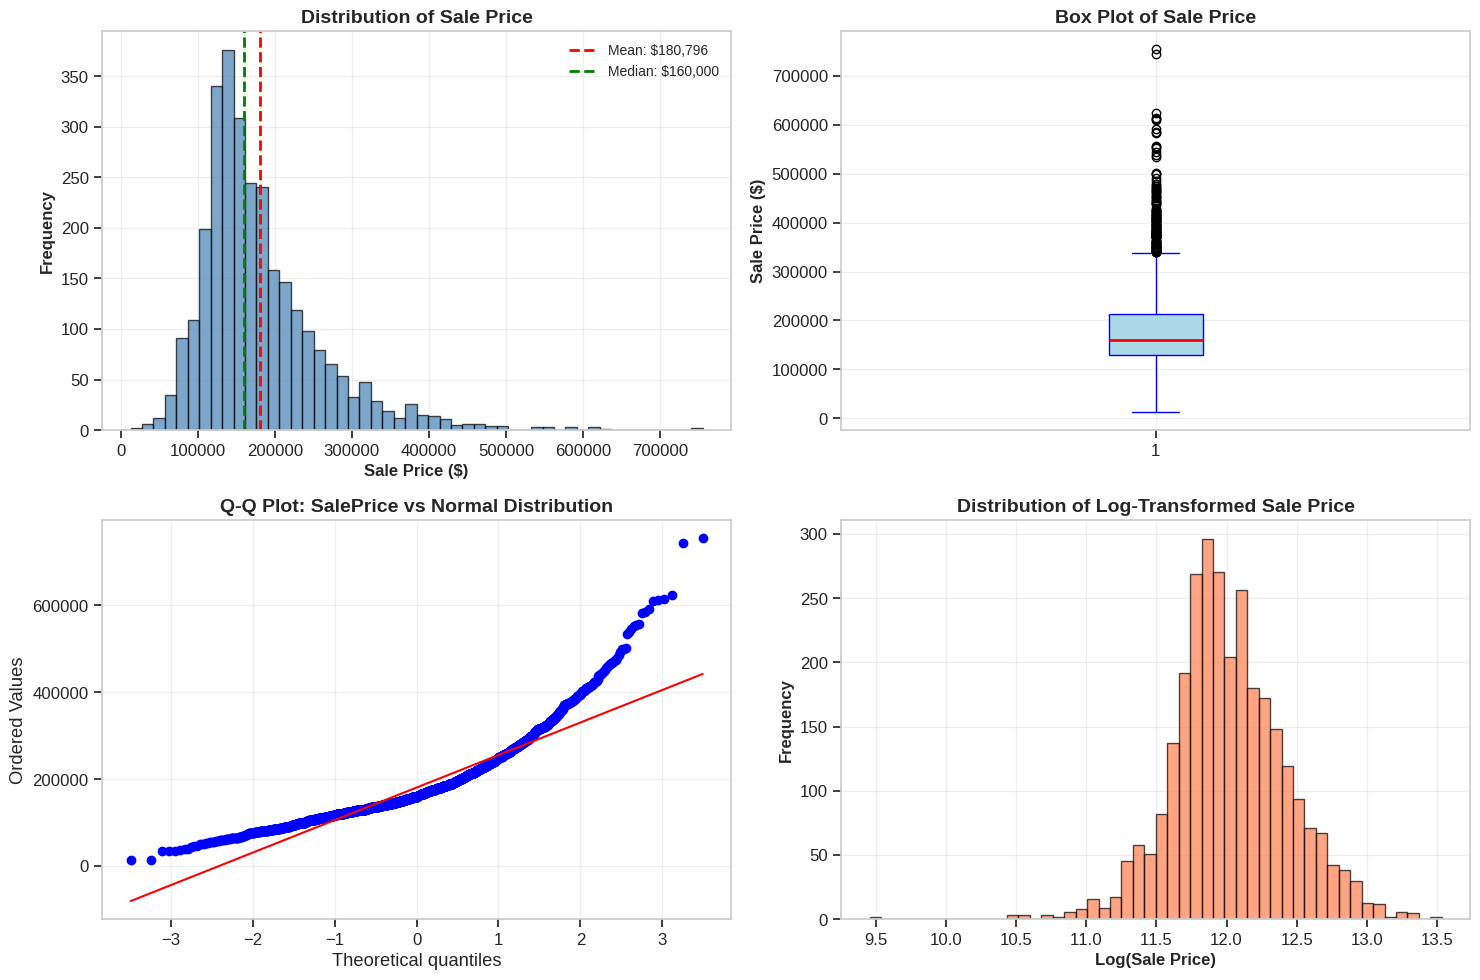

✓ Saved: 02_target_distribution.png

Target variable statistics:
  • Mean: $180,796.06
  • Median: $160,000.00
  • Std Dev: $79,886.69
  • Skewness: 1.7435


In [ ]:
print("\n4.1.1. Distribution of the Target Variable (SalePrice)")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
ax1 = axes[0, 0]
ax1.hist(df_original['SalePrice'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df_original['SalePrice'].mean(), color='red', linestyle='--',
            linewidth=2, label=f"Mean: ${df_original['SalePrice'].mean():,.0f}")
ax1.axvline(df_original['SalePrice'].median(), color='green', linestyle='--',
            linewidth=2, label=f"Median: ${df_original['SalePrice'].median():,.0f}")
ax1.set_xlabel('Sale Price ($)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Sale Price', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Box plot
ax2 = axes[0, 1]
ax2.boxplot(df_original['SalePrice'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'))
ax2.set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
ax2.set_title('Box Plot of Sale Price', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

# Q-Q plot
ax3 = axes[1, 0]
stats.probplot(df_original['SalePrice'], dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot: SalePrice vs Normal Distribution', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)

# Log-transformed distribution
ax4 = axes[1, 1]
log_prices = np.log1p(df_original['SalePrice'])
ax4.hist(log_prices, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax4.set_xlabel('Log(Sale Price)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Distribution of Log-Transformed Sale Price', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 02_target_distribution.png")
print(f"\nTarget variable statistics:")
print(f"  • Mean: ${df_original['SalePrice'].mean():,.2f}")
print(f"  • Median: ${df_original['SalePrice'].median():,.2f}")
print(f"  • Std Dev: ${df_original['SalePrice'].std():,.2f}")
print(f"  • Skewness: {df_original['SalePrice'].skew():.4f}")

#4.1.2. Distribution of a Key Numerical Feature (Gr Liv Area)


4.1.2. Distribution of a Key Numerical Feature (Gr Liv Area)


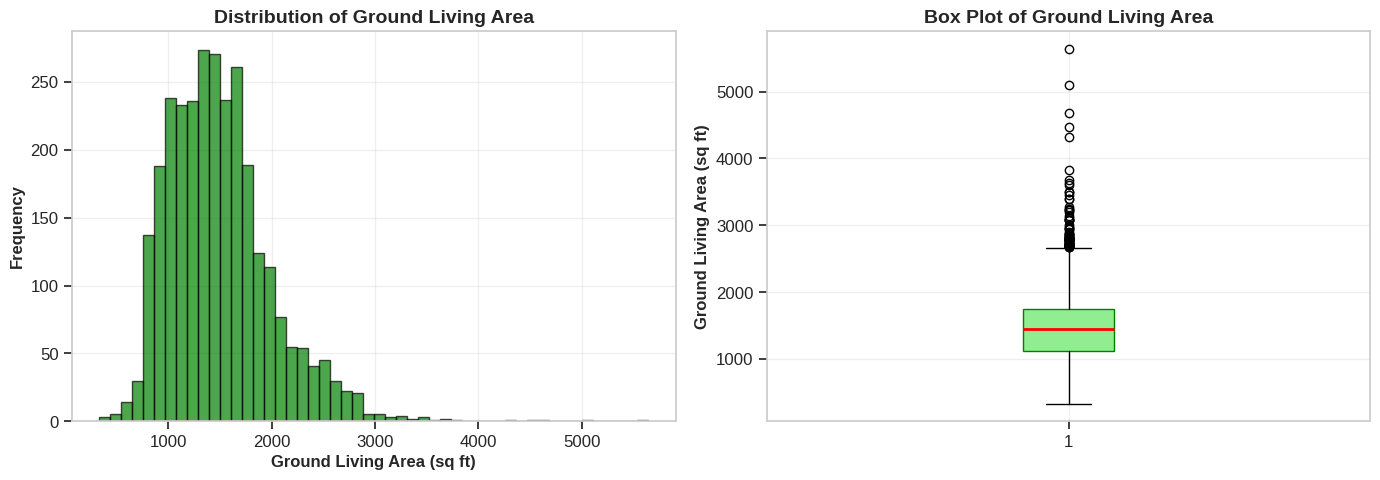

✓ Saved: 03_numerical_feature_distribution.png


In [ ]:
print("\n4.1.2. Distribution of a Key Numerical Feature (Gr Liv Area)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(df_original['Gr Liv Area'], bins=50, edgecolor='black', alpha=0.7, color='green')
ax1.set_xlabel('Ground Living Area (sq ft)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Ground Living Area', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

# Box plot
ax2 = axes[1]
ax2.boxplot(df_original['Gr Liv Area'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='green'),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Ground Living Area (sq ft)', fontsize=12, fontweight='bold')
ax2.set_title('Box Plot of Ground Living Area', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_numerical_feature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 03_numerical_feature_distribution.png")

#4.1.3. Distribution of a Key Categorical Feature (Neighborhood)


4.1.3. Distribution of a Key Categorical Feature (Neighborhood)


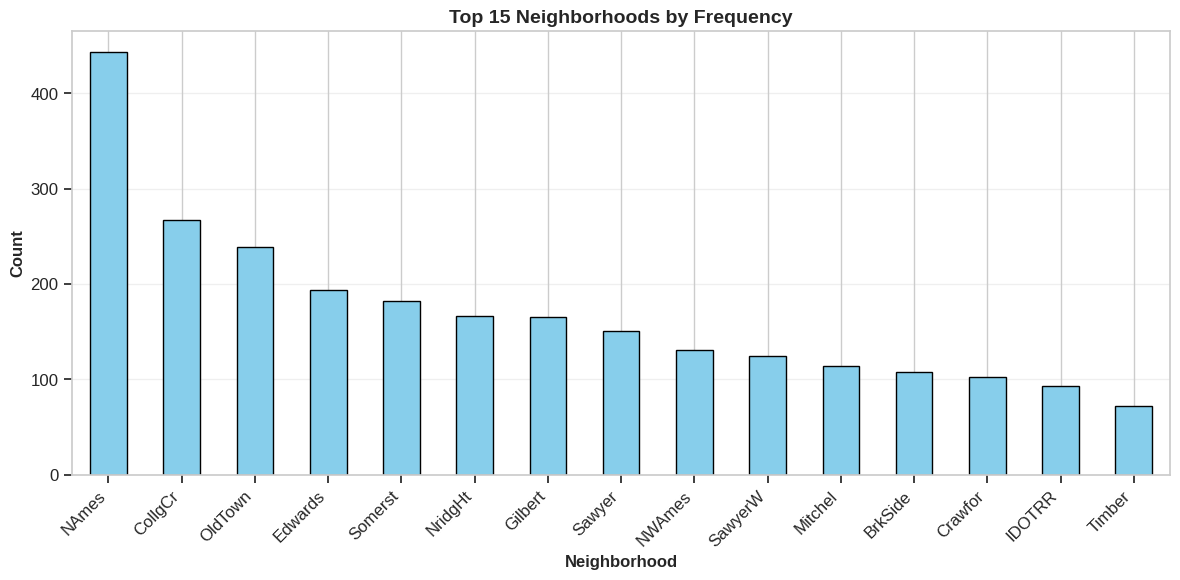

✓ Saved: 04_categorical_feature_distribution.png


In [ ]:
print("\n4.1.3. Distribution of a Key Categorical Feature (Neighborhood)")

neighborhood_counts = df_original['Neighborhood'].value_counts().head(15)

plt.figure(figsize=(12, 6))
neighborhood_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Neighborhood', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Top 15 Neighborhoods by Frequency', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('04_categorical_feature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 04_categorical_feature_distribution.png")


#4.1.4. Distribution of High-Cardinality Feature (Bldg Type)


4.1.4. Distribution of High-Cardinality Feature (Bldg Type)


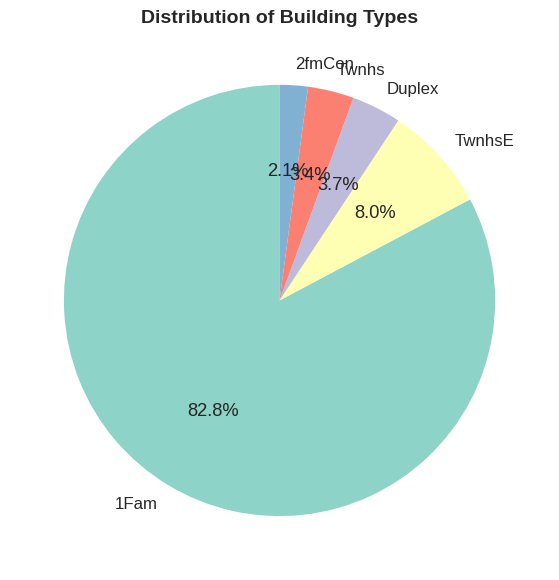

✓ Saved: 05_high_cardinality_distribution.png


In [ ]:
print("\n4.1.4. Distribution of High-Cardinality Feature (Bldg Type)")

bldg_type_counts = df_original['Bldg Type'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(bldg_type_counts.values, labels=bldg_type_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('Set3'))
plt.title('Distribution of Building Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_high_cardinality_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 05_high_cardinality_distribution.png")

##4.2. BIVARIATE ANALYSIS (FEATURE VS. TARGET VARIABLE)

#4.2.1. Numerical vs. Target (Gr Liv Area vs. SalePrice)


4.2.1. Numerical vs. Target (Gr Liv Area vs. SalePrice)


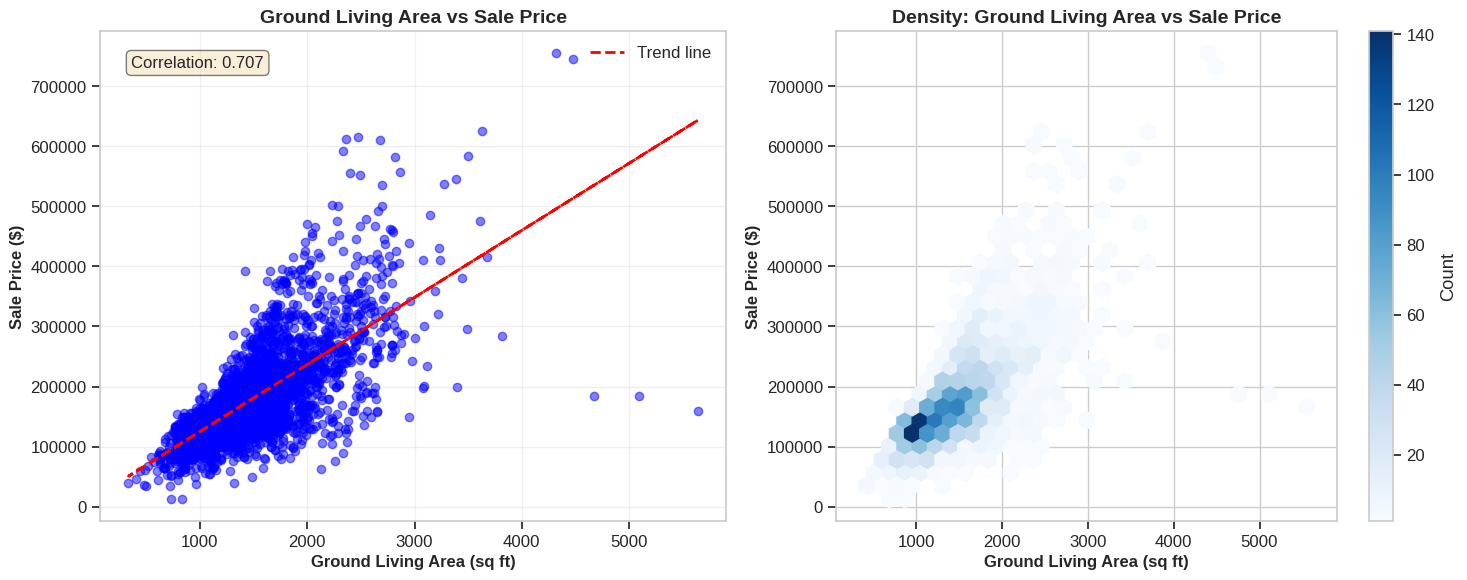

✓ Saved: 06_bivariate_numerical1.png
  Correlation: 0.7068


In [ ]:
print("\n4.2.1. Numerical vs. Target (Gr Liv Area vs. SalePrice)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
ax1 = axes[0]
ax1.scatter(df_original['Gr Liv Area'], df_original['SalePrice'], alpha=0.5, color='blue')
z = np.polyfit(df_original['Gr Liv Area'], df_original['SalePrice'], 1)
p = np.poly1d(z)
ax1.plot(df_original['Gr Liv Area'], p(df_original['Gr Liv Area']),
         "r--", linewidth=2, label=f'Trend line')
ax1.set_xlabel('Ground Living Area (sq ft)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
ax1.set_title('Ground Living Area vs Sale Price', fontsize=14, fontweight='bold')
correlation = df_original[['Gr Liv Area', 'SalePrice']].corr().iloc[0, 1]
ax1.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
         transform=ax1.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax1.legend()
ax1.grid(alpha=0.3)

# Joint plot style with histograms
ax2 = axes[1]
ax2.hexbin(df_original['Gr Liv Area'], df_original['SalePrice'],
           gridsize=30, cmap='Blues', mincnt=1)
ax2.set_xlabel('Ground Living Area (sq ft)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
ax2.set_title('Density: Ground Living Area vs Sale Price', fontsize=14, fontweight='bold')
plt.colorbar(ax2.collections[0], ax=ax2, label='Count')

plt.tight_layout()
plt.savefig('06_bivariate_numerical1.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 06_bivariate_numerical1.png")
print(f"  Correlation: {correlation:.4f}")

#4.2.2. Numerical vs. Target (Overall Qual vs. SalePrice)


4.2.2. Numerical vs. Target (Overall Qual vs. SalePrice)


<Figure size 1200x600 with 0 Axes>

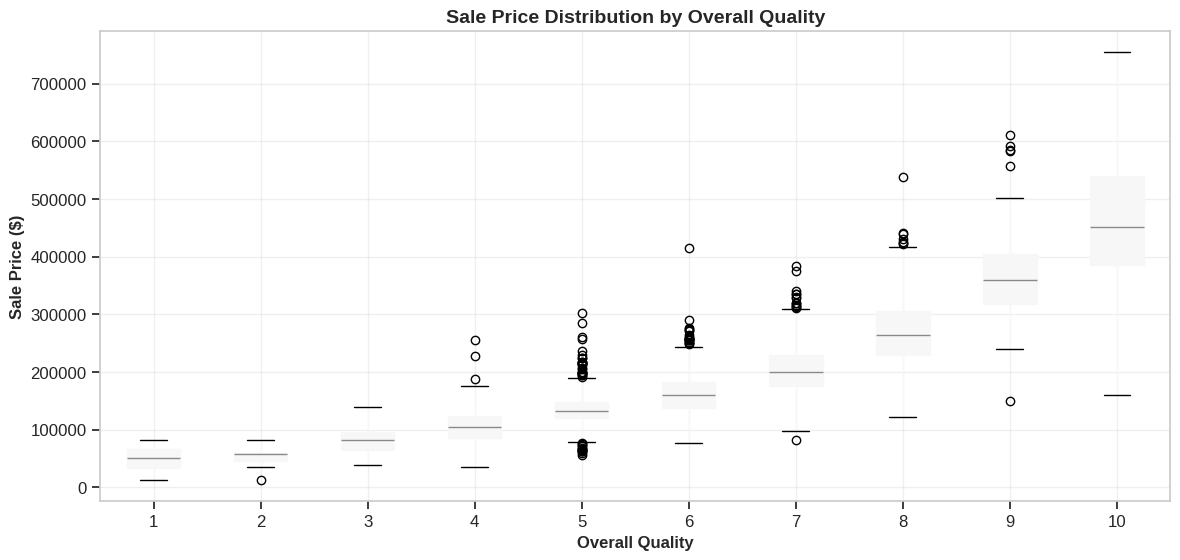

✓ Saved: 07_bivariate_numerical2.png


In [ ]:
print("\n4.2.2. Numerical vs. Target (Overall Qual vs. SalePrice)")

plt.figure(figsize=(12, 6))
df_original.boxplot(column='SalePrice', by='Overall Qual', figsize=(12, 6),
                    patch_artist=True, grid=False)
plt.xlabel('Overall Quality', fontsize=12, fontweight='bold')
plt.ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
plt.title('Sale Price Distribution by Overall Quality', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('07_bivariate_numerical2.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 07_bivariate_numerical2.png")

#4.2.3. Categorical vs. Target (Neighborhood vs. SalePrice)


4.2.3. Categorical vs. Target (Neighborhood vs. SalePrice)


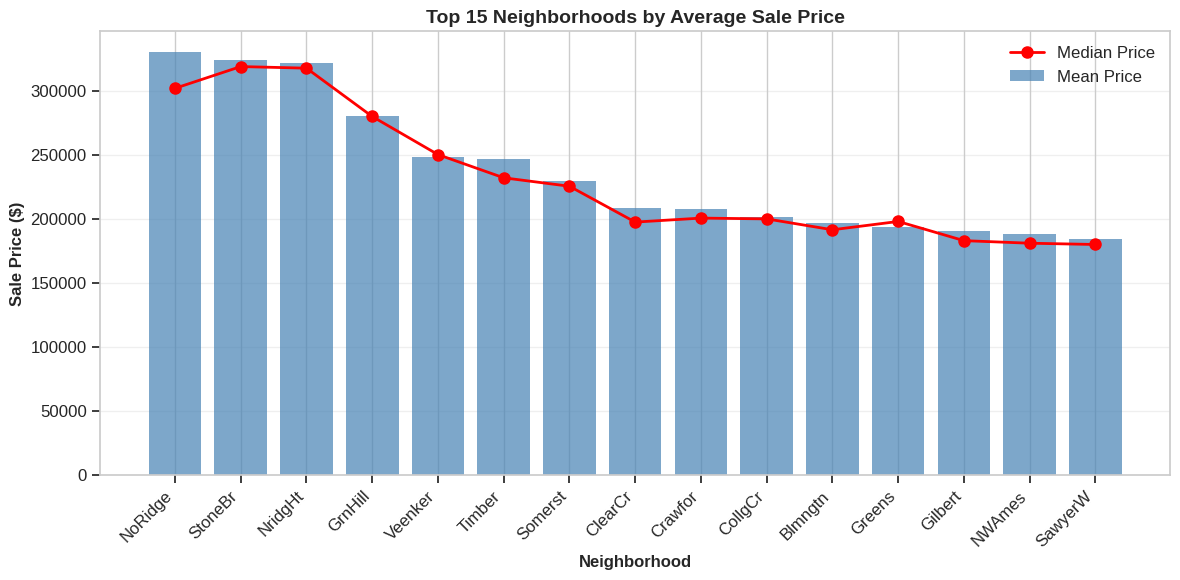

✓ Saved: 08_bivariate_categorical1.png


In [ ]:
print("\n4.2.3. Categorical vs. Target (Neighborhood vs. SalePrice)")

# Calculate mean price by neighborhood
neighborhood_price = df_original.groupby('Neighborhood')['SalePrice'].agg(['mean', 'median', 'count'])
neighborhood_price = neighborhood_price.sort_values('mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(neighborhood_price))
ax.bar(x, neighborhood_price['mean'], alpha=0.7, label='Mean Price', color='steelblue')
ax.plot(x, neighborhood_price['median'], 'ro-', linewidth=2, markersize=8, label='Median Price')
ax.set_xticks(x)
ax.set_xticklabels(neighborhood_price.index, rotation=45, ha='right')
ax.set_xlabel('Neighborhood', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Neighborhoods by Average Sale Price', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('08_bivariate_categorical1.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 08_bivariate_categorical1.png")


#4.2.4. Categorical vs. Target (Bldg Type vs. SalePrice)


4.2.4. Categorical vs. Target (Bldg Type vs. SalePrice)


<Figure size 1000x600 with 0 Axes>

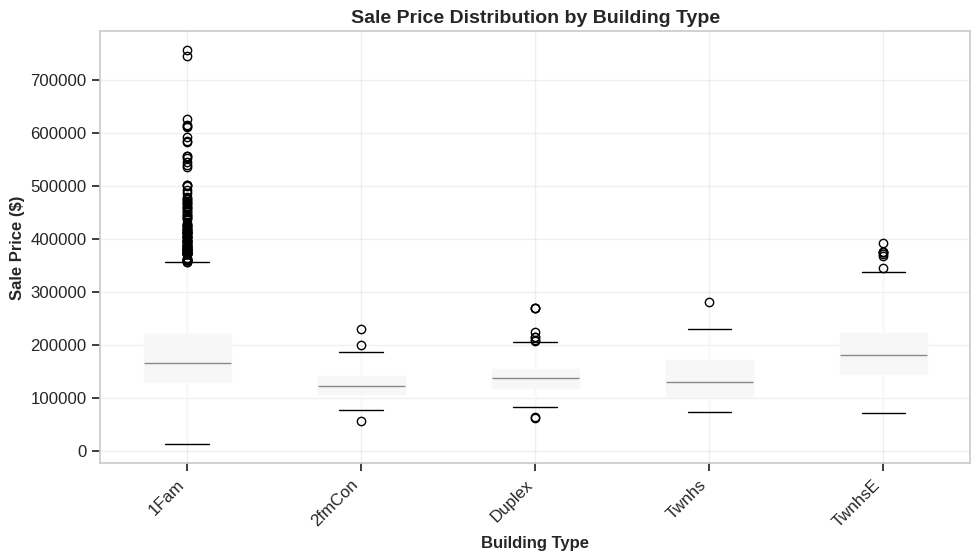

✓ Saved: 09_bivariate_categorical2.png


In [ ]:
print("\n4.2.4. Categorical vs. Target (Bldg Type vs. SalePrice)")

plt.figure(figsize=(10, 6))
df_original.boxplot(column='SalePrice', by='Bldg Type', figsize=(10, 6), patch_artist=True)
plt.xlabel('Building Type', fontsize=12, fontweight='bold')
plt.ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
plt.title('Sale Price Distribution by Building Type', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('09_bivariate_categorical2.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 09_bivariate_categorical2.png")

##4.3. GLOBAL COMPARISON (OVERALL RELATIONSHIPS)

#4.3.1. Correlation Heatmap (Key Numerical Features)


4.3.1. Correlation Heatmap (Key Numerical Features)
Type of correlations: <class 'pandas.core.series.Series'>


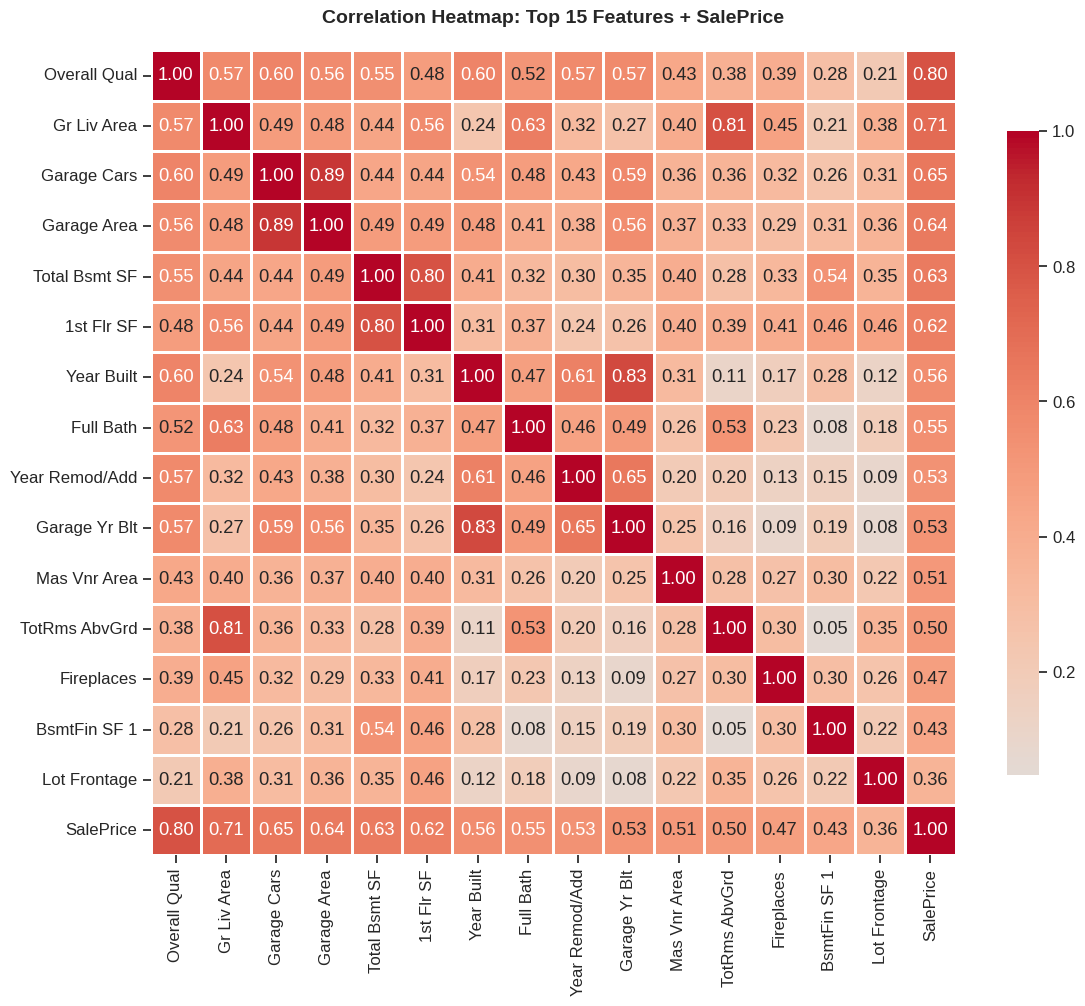

✓ Saved: 10_correlation_heatmap.png

Top 10 features correlated with SalePrice:
  1. Overall Qual: 0.7993
  2. Gr Liv Area: 0.7068
  3. Garage Cars: 0.6479
  4. Garage Area: 0.6404
  5. Total Bsmt SF: 0.6323
  6. 1st Flr SF: 0.6217
  7. Year Built: 0.5584
  8. Full Bath: 0.5456
  9. Year Remod/Add: 0.5330
  10. Garage Yr Blt: 0.5270


In [ ]:


print("\n4.3.1. Correlation Heatmap (Key Numerical Features)")

# Define numeric features from the original dataframe
numeric_features = df_original.select_dtypes(include=[np.number]).columns.tolist()

# Select key numerical features, ensuring 'SalePrice' is included only once for correlation matrix calculation
numeric_features_for_corr_matrix = [col for col in numeric_features
                          if col not in ['Order', 'PID']]

# Calculate full correlation matrix
corr_full = df_original[numeric_features_for_corr_matrix].corr()

# Extract correlations with SalePrice as a Series
correlations = corr_full['SalePrice']
correlations = correlations[correlations.index != 'SalePrice'] # Remove self-correlation of SalePrice

# Verify it's a Series now
print(f"Type of correlations: {type(correlations)}")

# Get top 15 features by absolute correlation value
correlations_abs = correlations.abs()
top_15_correlations = correlations_abs.sort_values(ascending=False).head(15)
top_features = top_15_correlations.index.tolist()

# Create correlation matrix for top features only
corr_matrix = df_original[top_features + ['SalePrice']].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 15 Features + SalePrice',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('10_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 10_correlation_heatmap.png")

# Print top 10 correlations
print(f"\nTop 10 features correlated with SalePrice:")
top_10 = correlations.abs().sort_values(ascending=False).head(10)
for i, feat in enumerate(top_10.index, 1):
    actual_corr = correlations[feat]
    print(f"  {i}. {feat}: {actual_corr:.4f}")

#4.3.2. Pair Plot of Top Predictors


4.3.2. Pair Plot of Top Predictors


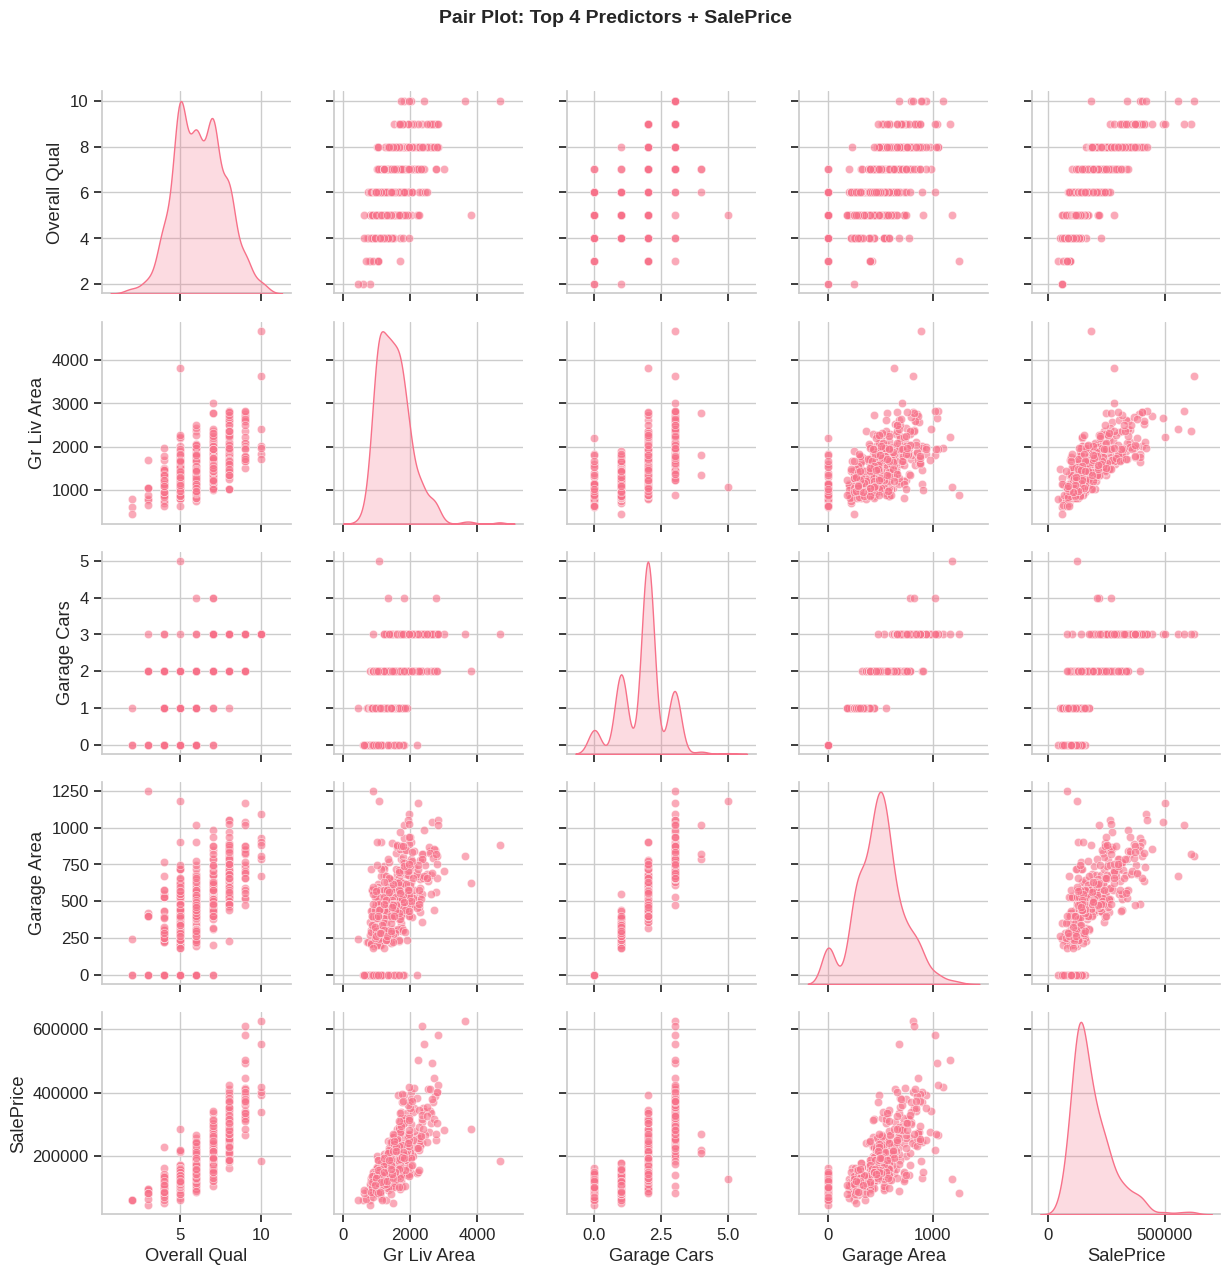

✓ Saved: 11_pairplot.png


In [ ]:
print("\n4.3.2. Pair Plot of Top Predictors")

# Select top 4 features for pair plot (to keep it readable)
top_4_features = correlations.abs().sort_values(ascending=False).head(4).index.tolist()

pair_data = df_original[top_4_features + ['SalePrice']].sample(min(500, len(df_original)), random_state=42)

sns.pairplot(pair_data, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot: Top 4 Predictors + SalePrice', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: 11_pairplot.png")

##4.4. KEY TAKEAWAYS (EDA)

In [ ]:
print("\n" + "-"*80)
print("4.4. KEY TAKEAWAYS (EDA)")
print("-"*80)

print("\n--- Key Findings from Exploratory Data Analysis ---")
print("\n1. Target Variable (SalePrice):")
print(f"   • Highly right-skewed (skewness: {df_original['SalePrice'].skew():.2f})")
print(f"   • Range: ${df_original['SalePrice'].min():,.0f} - ${df_original['SalePrice'].max():,.0f}")
print(f"   • Log transformation will improve model performance")

print("\n2. Missing Values:")
print(f"   • {len(missing_df)} columns had missing values")
print(f"   • {len(high_missing_cols)} columns dropped (>50% missing)")
print(f"   • Remaining missing values handled with median/mode imputation")

print("\n3. Feature Relationships:")
print(f"   • Strongest positive correlations with SalePrice:")
for feat in correlations.abs().sort_values(ascending=False).head(3).index:
    print(f"     - {feat}: {correlations[feat]:.3f}")

print("\n4. Categorical Features:")
print(f"   • Neighborhood shows significant price variation")
print(f"   • Building type affects price distribution")
print(f"   • Overall quality is a strong predictor")

print("\n5. Data Quality:")
print(f"   • {len(df_original)} total observations")
# print(f"   • {len(numeric_features_clean)} numeric features")
print(f"   • {len(categorical_features)} categorical features")
print(f"   • After encoding: {df_final.shape[1]} total features")

print("\n✓ EDA completed successfully!")


# Continue to Model Selection...
print("\n" + "="*80)
print("READY FOR MODEL TRAINING")
print("="*80)
print("\nNext step: Run the model implementation code (Part 2)")
print("This completes Part 1: Data Analysis and EDA")
print("="*80)



--------------------------------------------------------------------------------
4.4. KEY TAKEAWAYS (EDA)
--------------------------------------------------------------------------------

--- Key Findings from Exploratory Data Analysis ---

1. Target Variable (SalePrice):
   • Highly right-skewed (skewness: 1.74)
   • Range: $12,789 - $755,000
   • Log transformation will improve model performance

2. Missing Values:
   • 27 columns had missing values
   • 5 columns dropped (>50% missing)
   • Remaining missing values handled with median/mode imputation

3. Feature Relationships:
   • Strongest positive correlations with SalePrice:
     - Overall Qual: 0.799
     - Gr Liv Area: 0.707
     - Garage Cars: 0.648

4. Categorical Features:
   • Neighborhood shows significant price variation
   • Building type affects price distribution
   • Overall quality is a strong predictor

5. Data Quality:
   • 2930 total observations
   • 43 categorical features
   • After encoding: 247 total featur

###5. MODEL SELECTION, TRAINING AND COMPARISON

In [ ]:
# Import additional libraries for this section
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
print("\n--- Loading Preprocessed Data ---")
df = pd.read_csv('ames_housing_preprocessed.csv')
print(f"✓ Data loaded: {df.shape}")

# Prepare data
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Apply log transformation to target
y_log = np.log1p(y)
print(f"\n--- Target Transformation ---")
print(f"Original SalePrice: Mean=${y.mean():,.2f}, Std=${y.std():,.2f}")
print(f"Log-transformed: Mean={y_log.mean():.4f}, Std={y_log.std():.4f}")
print(f"✓ Log transformation applied to reduce skewness")

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n--- Data Split ---")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# For inverse transformation later
y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

# Initialize results storage
results = {
    'Model': [],
    'Train_RMSE': [],
    'Test_RMSE': [],
    'Train_R2': [],
    'Test_R2': [],
    'Train_MAE': [],
    'Test_MAE': [],
    'CV_Score_Mean': [],
    'CV_Score_Std': []
}


--- Loading Preprocessed Data ---
✓ Data loaded: (2930, 247)

--- Target Transformation ---
Original SalePrice: Mean=$180,796.06, Std=$79,886.69
Log-transformed: Mean=12.0210, Std=0.4076
✓ Log transformation applied to reduce skewness

--- Data Split ---
Training set: 2344 samples
Test set: 586 samples


##5.1. MODEL 1 - LINEAR BASELINE (ORDINARY LEAST SQUARES - OLS)

#5.1.1. Initialize and Train the Model

In [ ]:
print("\n5.1.1. Initialize and Train the Model")

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train_log)

print("✓ OLS model trained successfully")
print(f"  • Number of features used: {X_train.shape[1]}")
print(f"  • Intercept: {ols_model.intercept_:.4f}")
print(f"  • Non-zero coefficients: {np.sum(ols_model.coef_ != 0)}")



5.1.1. Initialize and Train the Model
✓ OLS model trained successfully
  • Number of features used: 246
  • Intercept: 12.0118
  • Non-zero coefficients: 246


#5.1.2. Make Predictions (log space)

In [ ]:
print("\n5.1.2. Make Predictions (log space)")

y_train_pred_log_ols = ols_model.predict(X_train_scaled)
y_test_pred_log_ols = ols_model.predict(X_test_scaled)

print("✓ Predictions generated in log space")


5.1.2. Make Predictions (log space)
✓ Predictions generated in log space


#5.1.3. Inverse Transform Predictions (real price space)

In [ ]:
print("\n5.1.3. Inverse Transform Predictions (real price space)")

y_train_pred_ols = np.expm1(y_train_pred_log_ols)
y_test_pred_ols = np.expm1(y_test_pred_log_ols)

print("✓ Predictions inverse transformed to original price scale")



5.1.3. Inverse Transform Predictions (real price space)
✓ Predictions inverse transformed to original price scale


#5.1.4. Evaluate Model Performance (using real prices)

In [ ]:
print("\n5.1.4. Evaluate Model Performance (using real prices)")

# Calculate metrics
ols_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ols))
ols_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ols))
ols_train_r2 = r2_score(y_train, y_train_pred_ols)
ols_test_r2 = r2_score(y_test, y_test_pred_ols)
ols_train_mae = mean_absolute_error(y_train, y_train_pred_ols)
ols_test_mae = mean_absolute_error(y_test, y_test_pred_ols)

# Cross-validation
cv_scores_ols = cross_val_score(ols_model, X_train_scaled, y_train_log,
                                 cv=5, scoring='neg_mean_squared_error')
cv_rmse_ols = np.sqrt(-cv_scores_ols)

print("\n--- OLS Performance Metrics ---")
print(f"Training RMSE: ${ols_train_rmse:,.2f}")
print(f"Test RMSE: ${ols_test_rmse:,.2f}")
print(f"Training R²: {ols_train_r2:.4f}")
print(f"Test R²: {ols_test_r2:.4f}")
print(f"Training MAE: ${ols_train_mae:,.2f}")
print(f"Test MAE: ${ols_test_mae:,.2f}")
print(f"Cross-validation RMSE: ${cv_rmse_ols.mean():,.2f} (±${cv_rmse_ols.std():,.2f})")

# Store results
results['Model'].append('OLS')
results['Train_RMSE'].append(ols_train_rmse)
results['Test_RMSE'].append(ols_test_rmse)
results['Train_R2'].append(ols_train_r2)
results['Test_R2'].append(ols_test_r2)
results['Train_MAE'].append(ols_train_mae)
results['Test_MAE'].append(ols_test_mae)
results['CV_Score_Mean'].append(cv_rmse_ols.mean())
results['CV_Score_Std'].append(cv_rmse_ols.std())


5.1.4. Evaluate Model Performance (using real prices)

--- OLS Performance Metrics ---
Training RMSE: $19,565.20
Test RMSE: $33,399.95
Training R²: 0.9356
Test R²: 0.8609
Training MAE: $12,095.19
Test MAE: $14,914.19
Cross-validation RMSE: $0.17 (±$0.01)


##5.2. MODEL 2 - REGULARIZED LINEAR (RIDGE REGRESSION)

#5.2.1. Initialize and Train the Model

In [ ]:
print("\n5.2.1. Initialize and Train the Model")
print("Performing hyperparameter tuning with GridSearchCV...")

# Define parameter grid
param_grid_ridge = {'alpha': np.logspace(-4, 4, 50)}

# Grid search with cross-validation
ridge_cv = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ridge_cv.fit(X_train_scaled, y_train_log)

print(f"\n✓ Ridge model trained with optimal hyperparameters")
print(f"  • Best alpha (λ): {ridge_cv.best_params_['alpha']:.6f}")
print(f"  • Best CV score: {np.sqrt(-ridge_cv.best_score_):,.4f}")
print(f"  • Number of features used: {X_train.shape[1]}")

# Get best model
ridge_model = ridge_cv.best_estimator_


5.2.1. Initialize and Train the Model
Performing hyperparameter tuning with GridSearchCV...

✓ Ridge model trained with optimal hyperparameters
  • Best alpha (λ): 494.171336
  • Best CV score: 0.1429
  • Number of features used: 246


#5.2.2. Make Predictions (log space)

In [ ]:
print("\n5.2.2. Make Predictions (log space)")

y_train_pred_log_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_log_ridge = ridge_model.predict(X_test_scaled)

print("✓ Predictions generated in log space")


5.2.2. Make Predictions (log space)
✓ Predictions generated in log space


#5.2.3. Inverse Transform Predictions (real price space)

In [ ]:
print("\n5.2.3. Inverse Transform Predictions (real price space)")

y_train_pred_ridge = np.expm1(y_train_pred_log_ridge)
y_test_pred_ridge = np.expm1(y_test_pred_log_ridge)

print("✓ Predictions inverse transformed to original price scale")


5.2.3. Inverse Transform Predictions (real price space)
✓ Predictions inverse transformed to original price scale


#5.2.4. Evaluate Model Performance (using real prices)

In [ ]:
print("\n5.2.4. Evaluate Model Performance (using real prices)")

# Calculate metrics
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)
ridge_train_mae = mean_absolute_error(y_train, y_train_pred_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)

# Cross-validation
cv_scores_ridge = cross_val_score(ridge_model, X_train_scaled, y_train_log,
                                   cv=5, scoring='neg_mean_squared_error')
cv_rmse_ridge = np.sqrt(-cv_scores_ridge)

print("\n--- Ridge Performance Metrics ---")
print(f"Training RMSE: ${ridge_train_rmse:,.2f}")
print(f"Test RMSE: ${ridge_test_rmse:,.2f}")
print(f"Training R²: {ridge_train_r2:.4f}")
print(f"Test R²: {ridge_test_r2:.4f}")
print(f"Training MAE: ${ridge_train_mae:,.2f}")
print(f"Test MAE: ${ridge_test_mae:,.2f}")
print(f"Cross-validation RMSE: ${cv_rmse_ridge.mean():,.2f} (±${cv_rmse_ridge.std():,.2f})")

# Store results
results['Model'].append('Ridge')
results['Train_RMSE'].append(ridge_train_rmse)
results['Test_RMSE'].append(ridge_test_rmse)
results['Train_R2'].append(ridge_train_r2)
results['Test_R2'].append(ridge_test_r2)
results['Train_MAE'].append(ridge_train_mae)
results['Test_MAE'].append(ridge_test_mae)
results['CV_Score_Mean'].append(cv_rmse_ridge.mean())
results['CV_Score_Std'].append(cv_rmse_ridge.std())



5.2.4. Evaluate Model Performance (using real prices)

--- Ridge Performance Metrics ---
Training RMSE: $24,997.89
Test RMSE: $31,279.05
Training R²: 0.8949
Test R²: 0.8780
Training MAE: $13,769.56
Test MAE: $15,939.35
Cross-validation RMSE: $0.14 (±$0.01)


##5.3. MODEL 3 - ENSEMBLE/NON-LINEAR (RANDOM FOREST REGRESSOR)

#5.3.1. Initialize and Train the Model

In [ ]:
print("\n5.3.1. Initialize and Train the Model")
print("Training Random Forest with default settings for initial comparison...")

# Note: Using scaled data for consistency, though RF doesn't require it
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_log)

print(f"\n✓ Random Forest model trained")
print(f"  • Number of trees: 100")
print(f"  • Number of features used: {X_train.shape[1]}")
print(f"  • Max depth: {rf_model.max_depth if rf_model.max_depth else 'Unlimited'}")



5.3.1. Initialize and Train the Model
Training Random Forest with default settings for initial comparison...

✓ Random Forest model trained
  • Number of trees: 100
  • Number of features used: 246
  • Max depth: Unlimited


#5.3.2. Make Predictions (log space)

In [ ]:
print("\n5.3.2. Make Predictions (log space)")

y_train_pred_log_rf = rf_model.predict(X_train_scaled)
y_test_pred_log_rf = rf_model.predict(X_test_scaled)

print("✓ Predictions generated in log space")



5.3.2. Make Predictions (log space)
✓ Predictions generated in log space


#5.3.3. Inverse Transform Predictions (real price space)

In [ ]:
print("\n5.3.3. Inverse Transform Predictions (real price space)")

y_train_pred_rf = np.expm1(y_train_pred_log_rf)
y_test_pred_rf = np.expm1(y_test_pred_log_rf)

print("✓ Predictions inverse transformed to original price scale")



5.3.3. Inverse Transform Predictions (real price space)
✓ Predictions inverse transformed to original price scale


#5.3.4. Evaluate Model Performance (using real prices)

In [ ]:
print("\n5.3.4. Evaluate Model Performance (using real prices)")

# Calculate metrics
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train_log,
                                cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse_rf = np.sqrt(-cv_scores_rf)

print("\n--- Random Forest Performance Metrics ---")
print(f"Training RMSE: ${rf_train_rmse:,.2f}")
print(f"Test RMSE: ${rf_test_rmse:,.2f}")
print(f"Training R²: {rf_train_r2:.4f}")
print(f"Test R²: {rf_test_r2:.4f}")
print(f"Training MAE: ${rf_train_mae:,.2f}")
print(f"Test MAE: ${rf_test_mae:,.2f}")
print(f"Cross-validation RMSE: ${cv_rmse_rf.mean():,.2f} (±${cv_rmse_rf.std():,.2f})")

# Store results
results['Model'].append('Random Forest')
results['Train_RMSE'].append(rf_train_rmse)
results['Test_RMSE'].append(rf_test_rmse)
results['Train_R2'].append(rf_train_r2)
results['Test_R2'].append(rf_test_r2)
results['Train_MAE'].append(rf_train_mae)
results['Test_MAE'].append(rf_test_mae)
results['CV_Score_Mean'].append(cv_rmse_rf.mean())
results['CV_Score_Std'].append(cv_rmse_rf.std())


5.3.4. Evaluate Model Performance (using real prices)

--- Random Forest Performance Metrics ---
Training RMSE: $10,592.03
Test RMSE: $27,785.69
Training R²: 0.9811
Test R²: 0.9037
Training MAE: $6,121.30
Test MAE: $16,190.44
Cross-validation RMSE: $0.15 (±$0.01)


##5.4. MODEL 4 - REGULARIZED LINEAR (LASSO REGRESSION)

#5.4.1. Initialize and Train the Model

In [ ]:
print("\n5.4.1. Initialize and Train the Model")
print("Performing hyperparameter tuning with GridSearchCV...")

# Define parameter grid
param_grid_lasso = {'alpha': np.logspace(-4, 4, 50)}

# Grid search with cross-validation
lasso_cv = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

lasso_cv.fit(X_train_scaled, y_train_log)

print(f"\n✓ Lasso model trained with optimal hyperparameters")
print(f"  • Best alpha (λ): {lasso_cv.best_params_['alpha']:.6f}")
print(f"  • Best CV score: {np.sqrt(-lasso_cv.best_score_):,.4f}")

# Get best model
lasso_model = lasso_cv.best_estimator_

# Feature selection analysis
non_zero_coef = np.sum(lasso_model.coef_ != 0)
zero_coef = np.sum(lasso_model.coef_ == 0)
print(f"  • Non-zero coefficients: {non_zero_coef} ({non_zero_coef/len(lasso_model.coef_)*100:.1f}%)")
print(f"  • Zero coefficients (eliminated): {zero_coef} ({zero_coef/len(lasso_model.coef_)*100:.1f}%)")
print(f"\n✓ Lasso performed automatic feature selection!")



5.4.1. Initialize and Train the Model
Performing hyperparameter tuning with GridSearchCV...

✓ Lasso model trained with optimal hyperparameters
  • Best alpha (λ): 0.002947
  • Best CV score: 0.1404
  • Non-zero coefficients: 114 (46.3%)
  • Zero coefficients (eliminated): 132 (53.7%)

✓ Lasso performed automatic feature selection!


#5.4.2. Make Predictions (log space)

In [ ]:
print("\n5.4.2. Make Predictions (log space)")

y_train_pred_log_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_log_lasso = lasso_model.predict(X_test_scaled)

print("✓ Predictions generated in log space")

#5.4.3. Inverse Transform Predictions (real price space)

In [ ]:
print("\n5.4.3. Inverse Transform Predictions (real price space)")

y_train_pred_lasso = np.expm1(y_train_pred_log_lasso)
y_test_pred_lasso = np.expm1(y_test_pred_log_lasso)

print("✓ Predictions inverse transformed to original price scale")



5.4.3. Inverse Transform Predictions (real price space)
✓ Predictions inverse transformed to original price scale


#5.4.4. Evaluate Performance (on original price scale)

In [ ]:
print("\n5.4.4. Evaluate Performance (on original price scale)")

# Calculate metrics
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)
lasso_train_mae = mean_absolute_error(y_train, y_train_pred_lasso)
lasso_test_mae = mean_absolute_error(y_test, y_test_pred_lasso)

# Cross-validation
cv_scores_lasso = cross_val_score(lasso_model, X_train_scaled, y_train_log,
                                   cv=5, scoring='neg_mean_squared_error')
cv_rmse_lasso = np.sqrt(-cv_scores_lasso)

print("\n--- Lasso Performance Metrics ---")
print(f"Training RMSE: ${lasso_train_rmse:,.2f}")
print(f"Test RMSE: ${lasso_test_rmse:,.2f}")
print(f"Training R²: {lasso_train_r2:.4f}")
print(f"Test R²: {lasso_test_r2:.4f}")
print(f"Training MAE: ${lasso_train_mae:,.2f}")
print(f"Test MAE: ${lasso_test_mae:,.2f}")
print(f"Cross-validation RMSE: ${cv_rmse_lasso.mean():,.2f} (±${cv_rmse_lasso.std():,.2f})")

# Store results
results['Model'].append('Lasso')
results['Train_RMSE'].append(lasso_train_rmse)
results['Test_RMSE'].append(lasso_test_rmse)
results['Train_R2'].append(lasso_train_r2)
results['Test_R2'].append(lasso_test_r2)
results['Train_MAE'].append(lasso_train_mae)
results['Test_MAE'].append(lasso_test_mae)
results['CV_Score_Mean'].append(cv_rmse_lasso.mean())
results['CV_Score_Std'].append(cv_rmse_lasso.std())



5.4.4. Evaluate Performance (on original price scale)

--- Lasso Performance Metrics ---
Training RMSE: $27,426.76
Test RMSE: $32,609.44
Training R²: 0.8735
Test R²: 0.8674
Training MAE: $14,113.66
Test MAE: $15,911.43
Cross-validation RMSE: $0.14 (±$0.01)


###6. FINAL MODEL EVALUATION

##6.1. MODEL COMPARISON TABLE

In [ ]:
# Create comparison DataFrame
results_df = pd.DataFrame(results)

print("\n--- Comprehensive Model Comparison ---")
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('model_comparison_comprehensive.csv', index=False)
print(f"\n✓ Results saved: model_comparison_comprehensive.csv")

# Identify best model
best_test_r2_idx = results_df['Test_R2'].idxmax()
best_test_rmse_idx = results_df['Test_RMSE'].idxmin()

print(f"\n--- Best Performing Models ---")
print(f"Best Test R²: {results_df.loc[best_test_r2_idx, 'Model']} (R² = {results_df.loc[best_test_r2_idx, 'Test_R2']:.4f})")
print(f"Lowest Test RMSE: {results_df.loc[best_test_rmse_idx, 'Model']} (RMSE = ${results_df.loc[best_test_rmse_idx, 'Test_RMSE']:,.2f})")



--- Comprehensive Model Comparison ---
        Model   Train_RMSE    Test_RMSE  Train_R2  Test_R2    Train_MAE     Test_MAE  CV_Score_Mean  CV_Score_Std
          OLS 19565.202062 33399.951980  0.935618 0.860861 12095.192414 14914.189813       0.170898      0.011982
        Ridge 24997.887627 31279.046219  0.894900 0.877970 13769.558064 15939.345544       0.142481      0.011329
Random Forest 10592.030119 27785.690798  0.981131 0.903706  6121.296549 16190.440006       0.145036      0.008882
        Lasso 27426.758339 32609.442254  0.873485 0.867369 14113.662364 15911.430086       0.139775      0.013264

✓ Results saved: model_comparison_comprehensive.csv

--- Best Performing Models ---
Best Test R²: Random Forest (R² = 0.9037)
Lowest Test RMSE: Random Forest (RMSE = $27,785.69)


##6.2. VISUALIZATION - MODEL COMPARISON


--------------------------------------------------------------------------------
6.2. VISUALIZATION - MODEL COMPARISON
--------------------------------------------------------------------------------


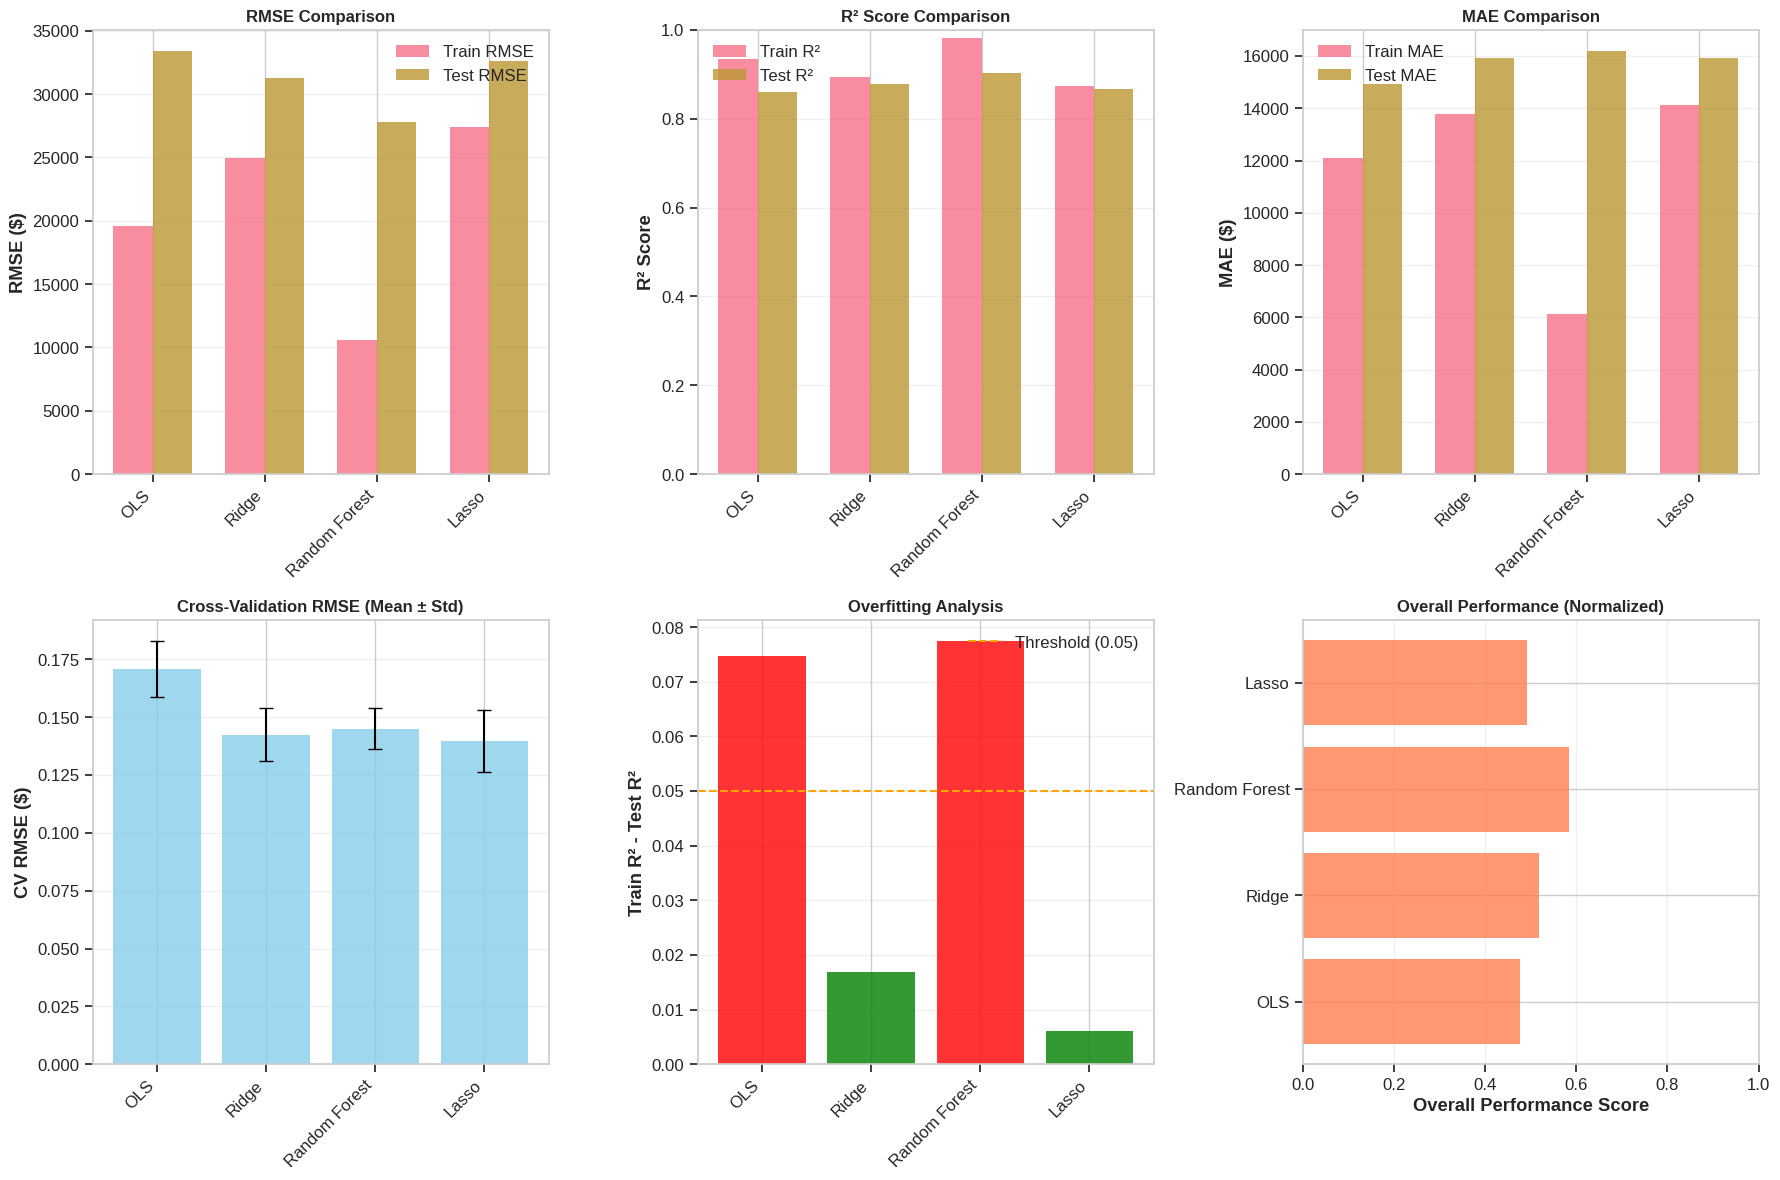


✓ Visualization saved: 12_comprehensive_model_comparison.png

MODEL SELECTION AND TRAINING COMPLETE!

Key Findings:
1. Total models trained: 4
2. Best model by Test R²: Random Forest
3. Best model by Test RMSE: Random Forest
4. Lasso eliminated 132 features (53.7%)

Next: Feature Importance Analysis and Final Visualization


In [ ]:
print("\n" + "-"*80)
print("6.2. VISUALIZATION - MODEL COMPARISON")
print("-"*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: RMSE Comparison
ax = axes[0, 0]
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Train_RMSE'], width, label='Train RMSE', alpha=0.8)
ax.bar(x + width/2, results_df['Test_RMSE'], width, label='Test RMSE', alpha=0.8)
ax.set_ylabel('RMSE ($)', fontweight='bold')
ax.set_title('RMSE Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: R² Comparison
ax = axes[0, 1]
ax.bar(x - width/2, results_df['Train_R2'], width, label='Train R²', alpha=0.8)
ax.bar(x + width/2, results_df['Test_R2'], width, label='Test R²', alpha=0.8)
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('R² Score Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 3: MAE Comparison
ax = axes[0, 2]
ax.bar(x - width/2, results_df['Train_MAE'], width, label='Train MAE', alpha=0.8)
ax.bar(x + width/2, results_df['Test_MAE'], width, label='Test MAE', alpha=0.8)
ax.set_ylabel('MAE ($)', fontweight='bold')
ax.set_title('MAE Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 4: Cross-Validation Scores
ax = axes[1, 0]
ax.bar(x, results_df['CV_Score_Mean'], yerr=results_df['CV_Score_Std'],
       capsize=5, alpha=0.8, color='skyblue')
ax.set_ylabel('CV RMSE ($)', fontweight='bold')
ax.set_title('Cross-Validation RMSE (Mean ± Std)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Plot 5: Overfitting Analysis
ax = axes[1, 1]
overfit_scores = results_df['Train_R2'] - results_df['Test_R2']
colors = ['red' if s > 0.05 else 'green' for s in overfit_scores]
ax.bar(x, overfit_scores, color=colors, alpha=0.8)
ax.set_ylabel('Train R² - Test R²', fontweight='bold')
ax.set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.axhline(y=0.05, color='orange', linestyle='--', label='Threshold (0.05)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 6: Overall Performance Score
ax = axes[1, 2]
# Normalize metrics (0-1 scale) and compute average
test_r2_norm = results_df['Test_R2'] / results_df['Test_R2'].max()
test_rmse_norm = 1 - (results_df['Test_RMSE'] / results_df['Test_RMSE'].max())
overall_score = (test_r2_norm + test_rmse_norm) / 2
ax.barh(x, overall_score, alpha=0.8, color='coral')
ax.set_xlabel('Overall Performance Score', fontweight='bold')
ax.set_title('Overall Performance (Normalized)', fontsize=12, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(results_df['Model'])
ax.set_xlim([0, 1])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('12_comprehensive_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved: 12_comprehensive_model_comparison.png")

print("\n" + "="*80)
print("MODEL SELECTION AND TRAINING COMPLETE!")
print("="*80)
print(f"\nKey Findings:")
print(f"1. Total models trained: {len(results_df)}")
print(f"2. Best model by Test R²: {results_df.loc[best_test_r2_idx, 'Model']}")
print(f"3. Best model by Test RMSE: {results_df.loc[best_test_rmse_idx, 'Model']}")
print(f"4. Lasso eliminated {zero_coef} features ({zero_coef/len(lasso_model.coef_)*100:.1f}%)")
print(f"\nNext: Feature Importance Analysis and Final Visualization")
print("="*80)


###7. FEATURE IMPORTANCE ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso, Ridge
import warnings
warnings.filterwarnings('ignore')

# Assuming models are already trained from Part 2
# For standalone execution, we'll reload necessary data

# Load preprocessed data
df = pd.read_csv('ames_housing_preprocessed.csv')
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Apply transformations
y_log = np.log1p(y)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain models (or load from saved models)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# OLS
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train_log)

# Ridge
param_grid_ridge = {'alpha': np.logspace(-4, 4, 50)}
ridge_cv = GridSearchCV(Ridge(), param_grid_ridge, cv=5,
                        scoring='neg_mean_squared_error', n_jobs=-1)
ridge_cv.fit(X_train_scaled, y_train_log)
ridge_model = ridge_cv.best_estimator_

# Lasso
param_grid_lasso = {'alpha': np.logspace(-4, 4, 50)}
lasso_cv = GridSearchCV(Lasso(max_iter=10000), param_grid_lasso, cv=5,
                        scoring='neg_mean_squared_error', n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train_log)
lasso_model = lasso_cv.best_estimator_

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_log)

RandomForestRegressor(n_jobs=-1, random_state=42)

##7.1. GET FEATURE IMPORTANCES FROM THE TRAINED MODELS

In [108]:
# For Random Forest, use built-in feature importances
rf_importances = rf_model.feature_importances_

# For linear models, use absolute coefficient values
ols_importances = np.abs(ols_model.coef_)
ridge_importances = np.abs(ridge_model.coef_)
lasso_importances = np.abs(lasso_model.coef_)

print("\n✓ Feature importances extracted from all models")
print(f"  • OLS: {len(ols_importances)} coefficients")
print(f"  • Ridge: {len(ridge_importances)} coefficients")
print(f"  • Lasso: {len(lasso_importances)} coefficients ({np.sum(lasso_importances > 0)} non-zero)")
print(f"  • Random Forest: {len(rf_importances)} importance scores")



✓ Feature importances extracted from all models
  • OLS: 246 coefficients
  • Ridge: 246 coefficients
  • Lasso: 246 coefficients (114 non-zero)
  • Random Forest: 246 importance scores


##7.2. MAP IMPORTANCES TO FEATURE NAMES AND CREATE A DATAFRAME

In [109]:
feature_names = X_train.columns.tolist()

# Create comprehensive feature importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'OLS_Importance': ols_importances,
    'Ridge_Importance': ridge_importances,
    'Lasso_Importance': lasso_importances,
    'RF_Importance': rf_importances,
    'Lasso_Selected': lasso_importances > 0
})

print("\n✓ Feature importance DataFrame created")
print(f"  • Total features: {len(feature_importance_df)}")
print(f"  • Features selected by Lasso: {feature_importance_df['Lasso_Selected'].sum()}")
print(f"  • Features eliminated by Lasso: {(~feature_importance_df['Lasso_Selected']).sum()}")

# Save full feature importance
feature_importance_df.to_csv('feature_importance_comprehensive.csv', index=False)
print(f"\n✓ Saved: feature_importance_comprehensive.csv")



✓ Feature importance DataFrame created
  • Total features: 246
  • Features selected by Lasso: 114
  • Features eliminated by Lasso: 132

✓ Saved: feature_importance_comprehensive.csv


##7.3. SELECTING AND SORTING THE TOP 10 FEATURES

In [110]:
# Top 10 by Random Forest
top_10_rf = feature_importance_df.nlargest(10, 'RF_Importance')

# Top 10 by Lasso (non-zero only)
lasso_nonzero = feature_importance_df[feature_importance_df['Lasso_Selected']]
top_10_lasso = lasso_nonzero.nlargest(10, 'Lasso_Importance')

# Top 10 by Ridge
top_10_ridge = feature_importance_df.nlargest(10, 'Ridge_Importance')

# Top 10 by OLS
top_10_ols = feature_importance_df.nlargest(10, 'OLS_Importance')

print("\n--- Top 10 Features by Random Forest ---")
print(top_10_rf[['Feature', 'RF_Importance']].to_string(index=False))

print("\n--- Top 10 Features by Lasso (L1 Regularization) ---")
print(top_10_lasso[['Feature', 'Lasso_Importance']].to_string(index=False))

print("\n--- Top 10 Features by Ridge (L2 Regularization) ---")
print(top_10_ridge[['Feature', 'Ridge_Importance']].to_string(index=False))

print("\n--- Top 10 Features by OLS ---")
print(top_10_ols[['Feature', 'OLS_Importance']].to_string(index=False))



--- Top 10 Features by Random Forest ---
       Feature  RF_Importance
  Overall Qual       0.584223
   Gr Liv Area       0.089689
   Garage Cars       0.041880
   Garage Area       0.041726
 Total Bsmt SF       0.030915
    1st Flr SF       0.028548
  BsmtFin SF 1       0.017250
    Year Built       0.015309
      Lot Area       0.013906
Year Remod/Add       0.010557

--- Top 10 Features by Lasso (L1 Regularization) ---
              Feature  Lasso_Importance
          Gr Liv Area          0.113984
         Overall Qual          0.096526
           Year Built          0.046557
         Overall Cond          0.038950
          Garage Cars          0.038251
       Functional_Sal          0.031125
 Neighborhood_NridgHt          0.026286
        Total Bsmt SF          0.021377
Sale Condition_Normal          0.020854
       Bsmt Full Bath          0.019561

--- Top 10 Features by Ridge (L2 Regularization) ---
             Feature  Ridge_Importance
        Overall Qual          0.058771
  

##7.4. PLOTTING THE RESULTS

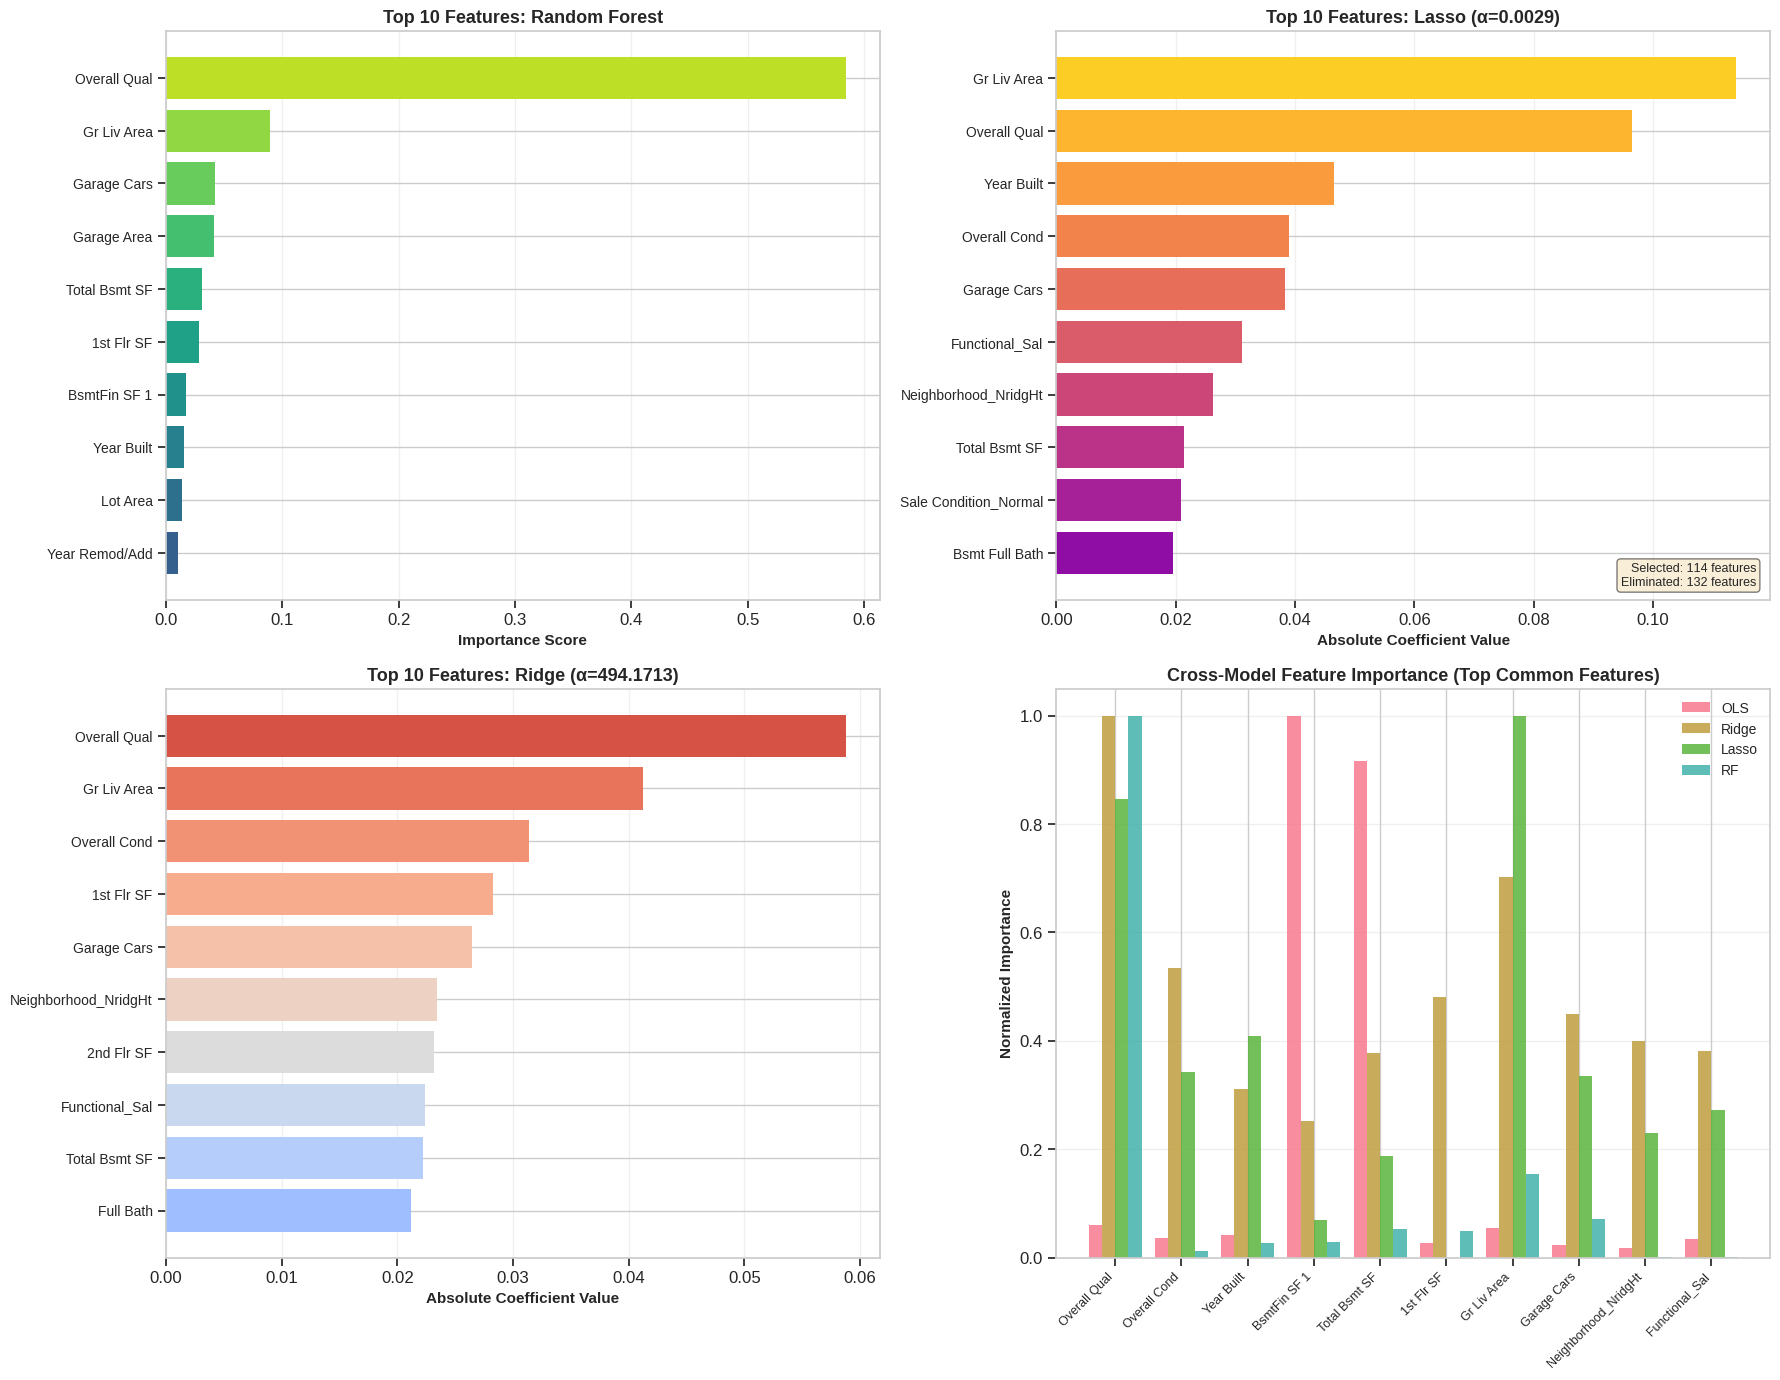


✓ Saved: 13_feature_importance_analysis.png


In [111]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Top 10 Random Forest Importances
ax = axes[0, 0]
colors_rf = plt.cm.viridis(np.linspace(0.3, 0.9, 10))
ax.barh(range(10), top_10_rf['RF_Importance'].values[::-1], color=colors_rf)
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_rf['Feature'].values[::-1], fontsize=10)
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Features: Random Forest', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 2: Top 10 Lasso Importances
ax = axes[0, 1]
colors_lasso = plt.cm.plasma(np.linspace(0.3, 0.9, 10))
ax.barh(range(10), top_10_lasso['Lasso_Importance'].values[::-1], color=colors_lasso)
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_lasso['Feature'].values[::-1], fontsize=10)
ax.set_xlabel('Absolute Coefficient Value', fontsize=11, fontweight='bold')
ax.set_title(f'Top 10 Features: Lasso (α={lasso_model.alpha:.4f})',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.text(0.98, 0.02, f'Selected: {feature_importance_df["Lasso_Selected"].sum()} features\n'
                     f'Eliminated: {(~feature_importance_df["Lasso_Selected"]).sum()} features',
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Top 10 Ridge Importances
ax = axes[1, 0]
colors_ridge = plt.cm.coolwarm(np.linspace(0.3, 0.9, 10))
ax.barh(range(10), top_10_ridge['Ridge_Importance'].values[::-1], color=colors_ridge)
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_ridge['Feature'].values[::-1], fontsize=10)
ax.set_xlabel('Absolute Coefficient Value', fontsize=11, fontweight='bold')
ax.set_title(f'Top 10 Features: Ridge (α={ridge_model.alpha:.4f})',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 4: Comparison of Top Features Across Models
ax = axes[1, 1]
# Get union of top 10 from each model
all_top_features = set(top_10_ols['Feature'].tolist() +
                       top_10_ridge['Feature'].tolist() +
                       top_10_lasso['Feature'].tolist() +
                       top_10_rf['Feature'].tolist())

# Select top 10 features that appear most frequently
feature_freq = {feat: sum([feat in top_10_ols['Feature'].values,
                           feat in top_10_ridge['Feature'].values,
                           feat in top_10_lasso['Feature'].values,
                           feat in top_10_rf['Feature'].values])
                for feat in all_top_features}
common_top_features = sorted(feature_freq.items(), key=lambda x: x[1], reverse=True)[:10]
common_features = [f[0] for f in common_top_features]

# Create comparison for these features
comparison_data = feature_importance_df[feature_importance_df['Feature'].isin(common_features)]
comparison_data = comparison_data.set_index('Feature')

# Normalize for comparison
comparison_normalized = comparison_data[['OLS_Importance', 'Ridge_Importance',
                                          'Lasso_Importance', 'RF_Importance']].copy()
for col in comparison_normalized.columns:
    comparison_normalized[col] = comparison_normalized[col] / comparison_normalized[col].max()

# Plot grouped bar chart
x = np.arange(len(comparison_normalized))
width = 0.2
ax.bar(x - 1.5*width, comparison_normalized['OLS_Importance'], width,
       label='OLS', alpha=0.8)
ax.bar(x - 0.5*width, comparison_normalized['Ridge_Importance'], width,
       label='Ridge', alpha=0.8)
ax.bar(x + 0.5*width, comparison_normalized['Lasso_Importance'], width,
       label='Lasso', alpha=0.8)
ax.bar(x + 1.5*width, comparison_normalized['RF_Importance'], width,
       label='RF', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comparison_normalized.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalized Importance', fontsize=11, fontweight='bold')
ax.set_title('Cross-Model Feature Importance (Top Common Features)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('13_feature_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 13_feature_importance_analysis.png")


###8. MODEL VISUALIZATION & FINAL SUMMARY

##8.1. PREDICTION VS ACTUAL PLOTS

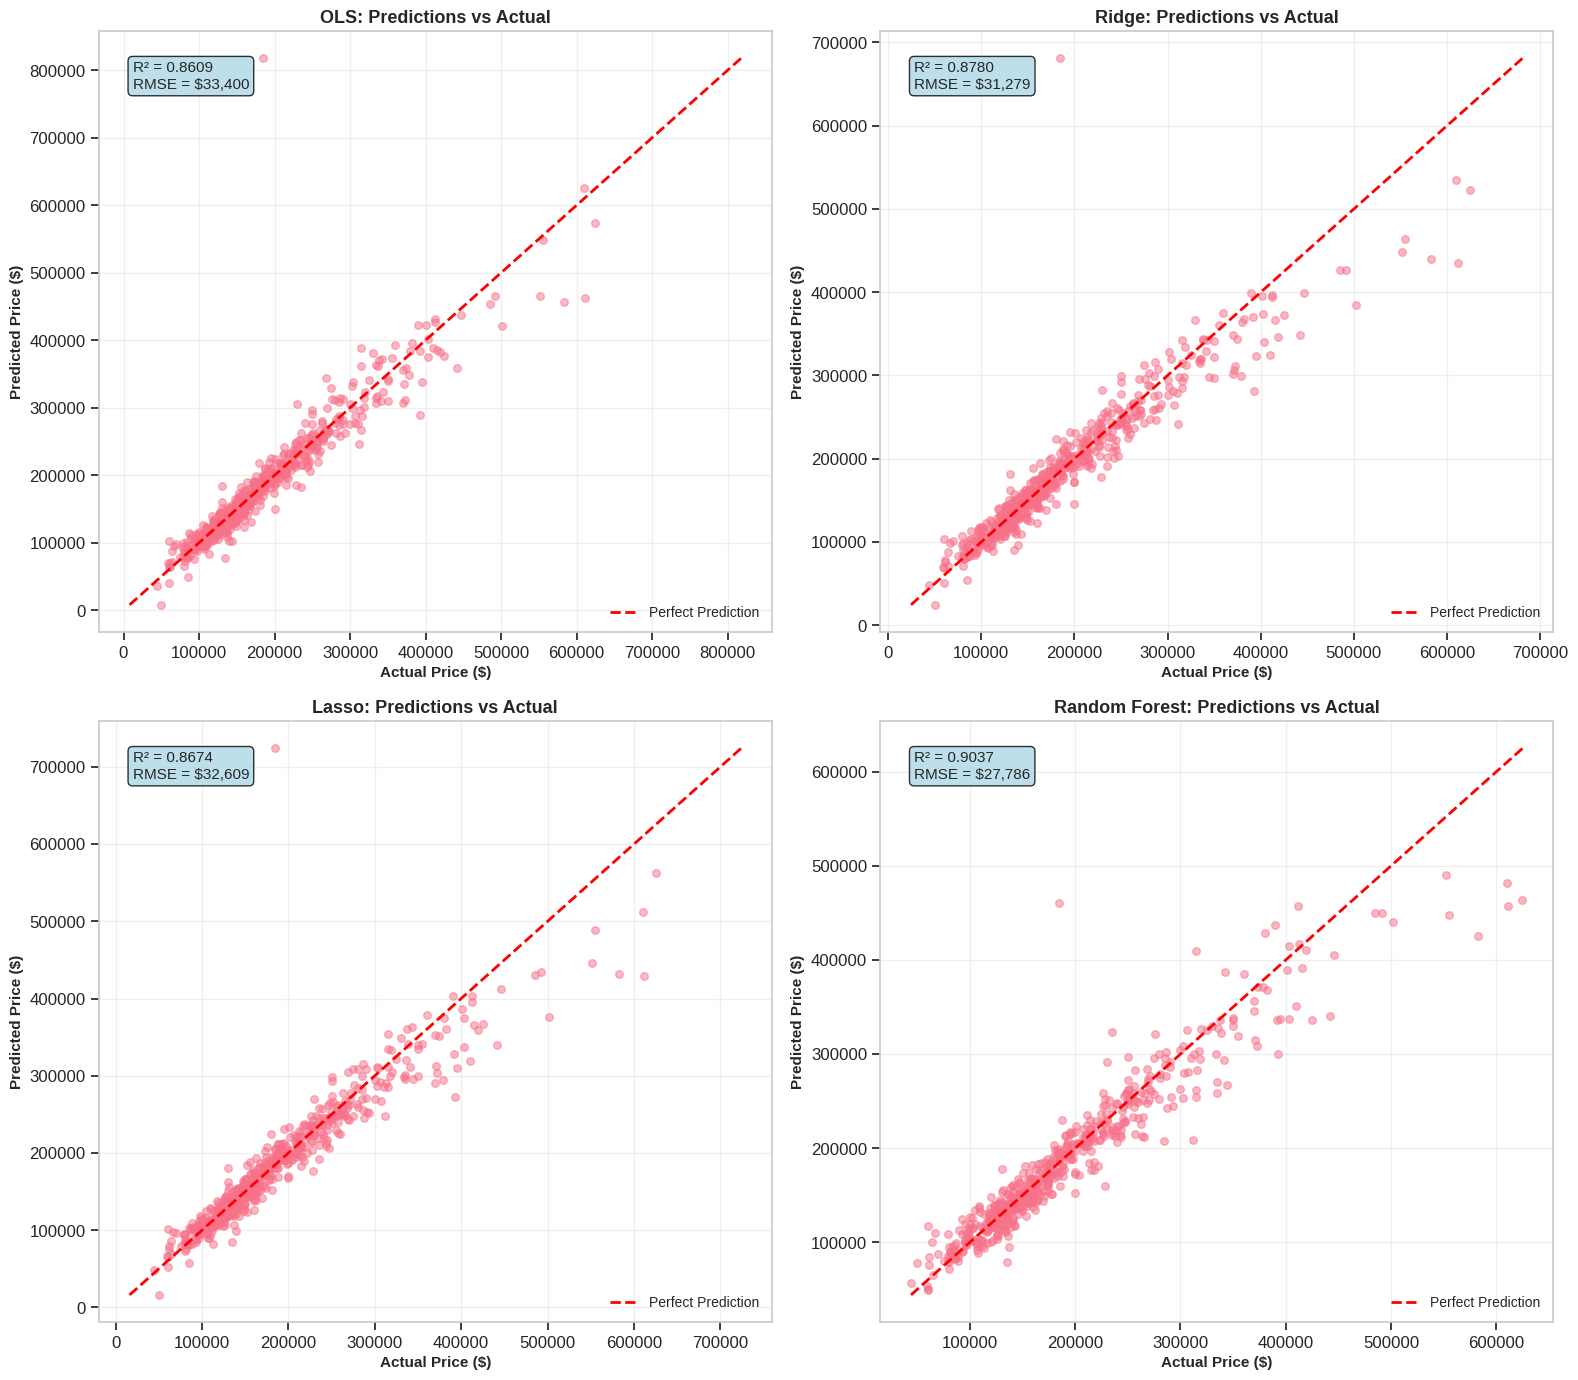


✓ Saved: 14_predictions_vs_actual.png


In [112]:
# Get predictions (inverse transformed)
y_test = np.expm1(y_test_log)
y_train = np.expm1(y_train_log)

# Generate predictions
y_test_pred_ols = np.expm1(ols_model.predict(X_test_scaled))
y_test_pred_ridge = np.expm1(ridge_model.predict(X_test_scaled))
y_test_pred_lasso = np.expm1(lasso_model.predict(X_test_scaled))
y_test_pred_rf = np.expm1(rf_model.predict(X_test_scaled))

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

models_data = [
    ('OLS', y_test_pred_ols, axes[0, 0]),
    ('Ridge', y_test_pred_ridge, axes[0, 1]),
    ('Lasso', y_test_pred_lasso, axes[1, 0]),
    ('Random Forest', y_test_pred_rf, axes[1, 1])
]

for model_name, y_pred, ax in models_data:
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.5, s=30)

    # Perfect prediction line
    max_val = max(y_test.max(), y_pred.max())
    min_val = min(y_test.min(), y_pred.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    # Calculate metrics
    from sklearn.metrics import r2_score, mean_squared_error
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    ax.set_xlabel('Actual Price ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Price ($)', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}: Predictions vs Actual', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    # Add metrics text box
    textstr = f'R² = {r2:.4f}\nRMSE = ${rmse:,.0f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('14_predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 14_predictions_vs_actual.png")


##8.2. RESIDUAL ANALYSIS

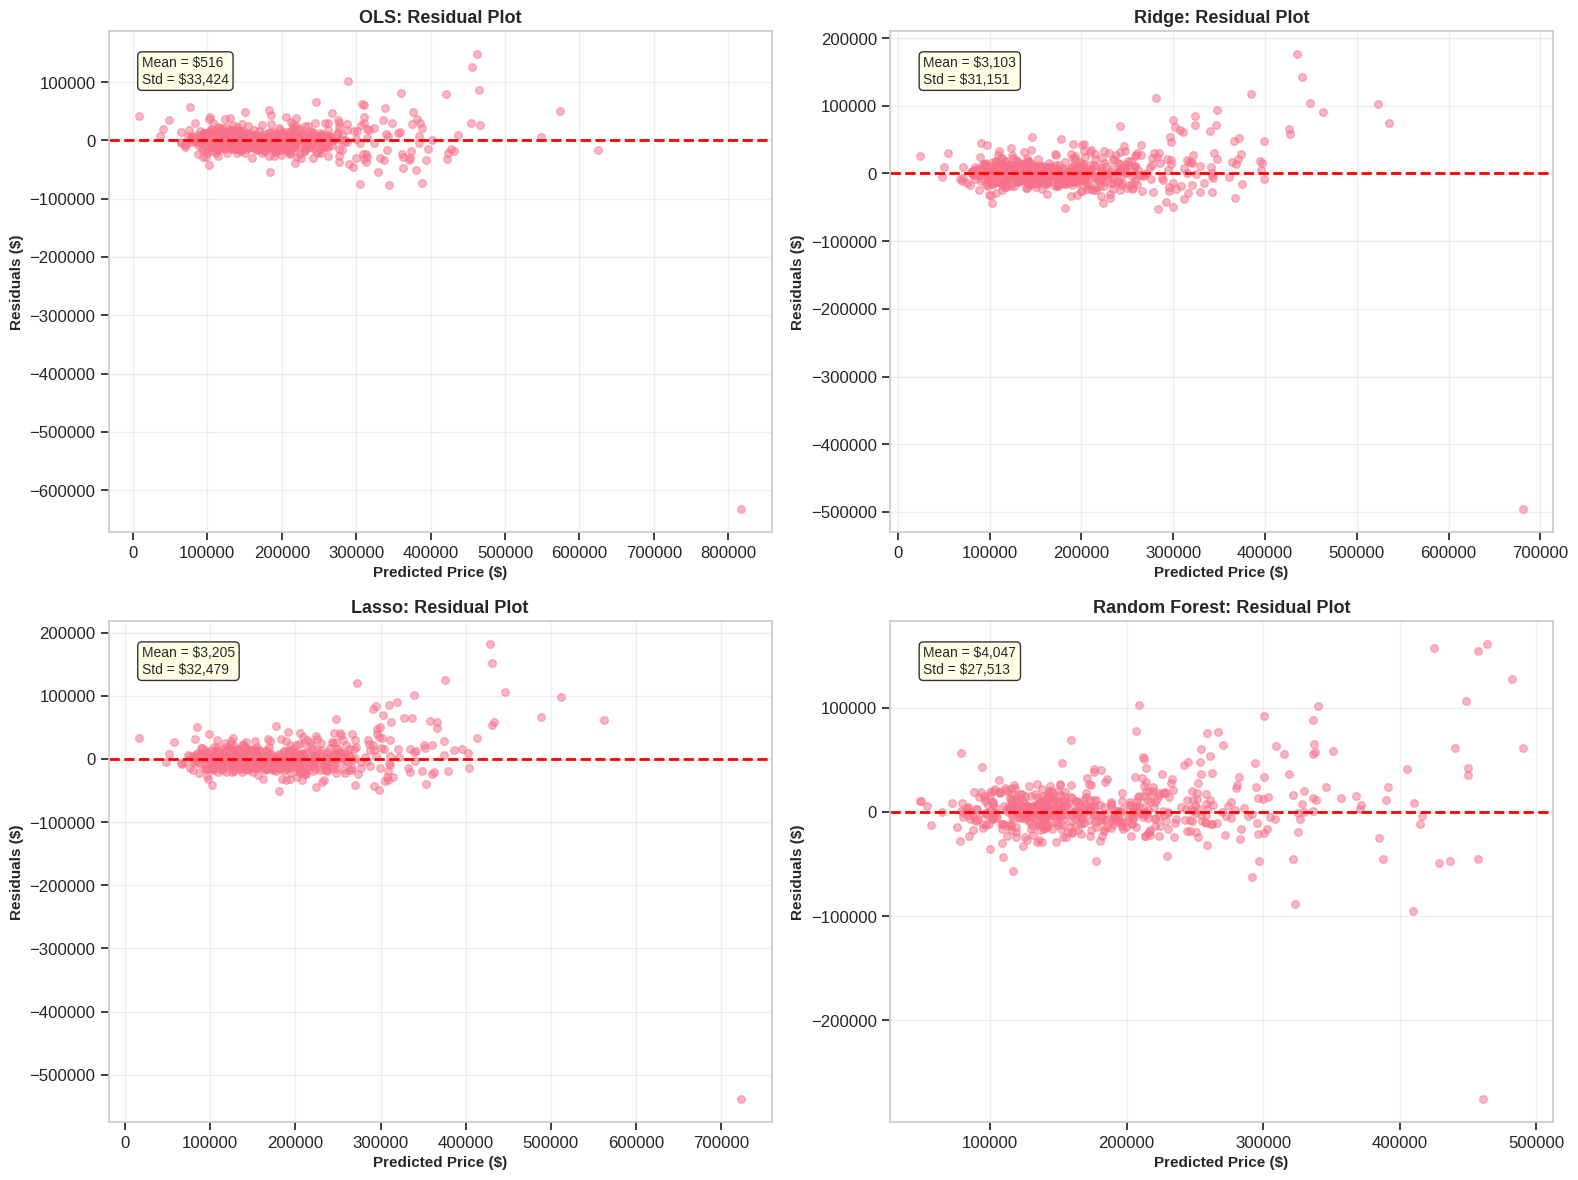


✓ Saved: 15_residual_analysis.png


In [113]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate residuals
residuals_data = [
    ('OLS', y_test - y_test_pred_ols, y_test_pred_ols, axes[0, 0]),
    ('Ridge', y_test - y_test_pred_ridge, y_test_pred_ridge, axes[0, 1]),
    ('Lasso', y_test - y_test_pred_lasso, y_test_pred_lasso, axes[1, 0]),
    ('Random Forest', y_test - y_test_pred_rf, y_test_pred_rf, axes[1, 1])
]

for model_name, residuals, predictions, ax in residuals_data:
    ax.scatter(predictions, residuals, alpha=0.5, s=30)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Price ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Residuals ($)', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}: Residual Plot', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)

    # Add statistics
    mean_resid = residuals.mean()
    std_resid = residuals.std()
    textstr = f'Mean = ${mean_resid:,.0f}\nStd = ${std_resid:,.0f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('15_residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 15_residual_analysis.png")

##8.3. REGULARIZATION PATH (LASSO vs RIDGE)

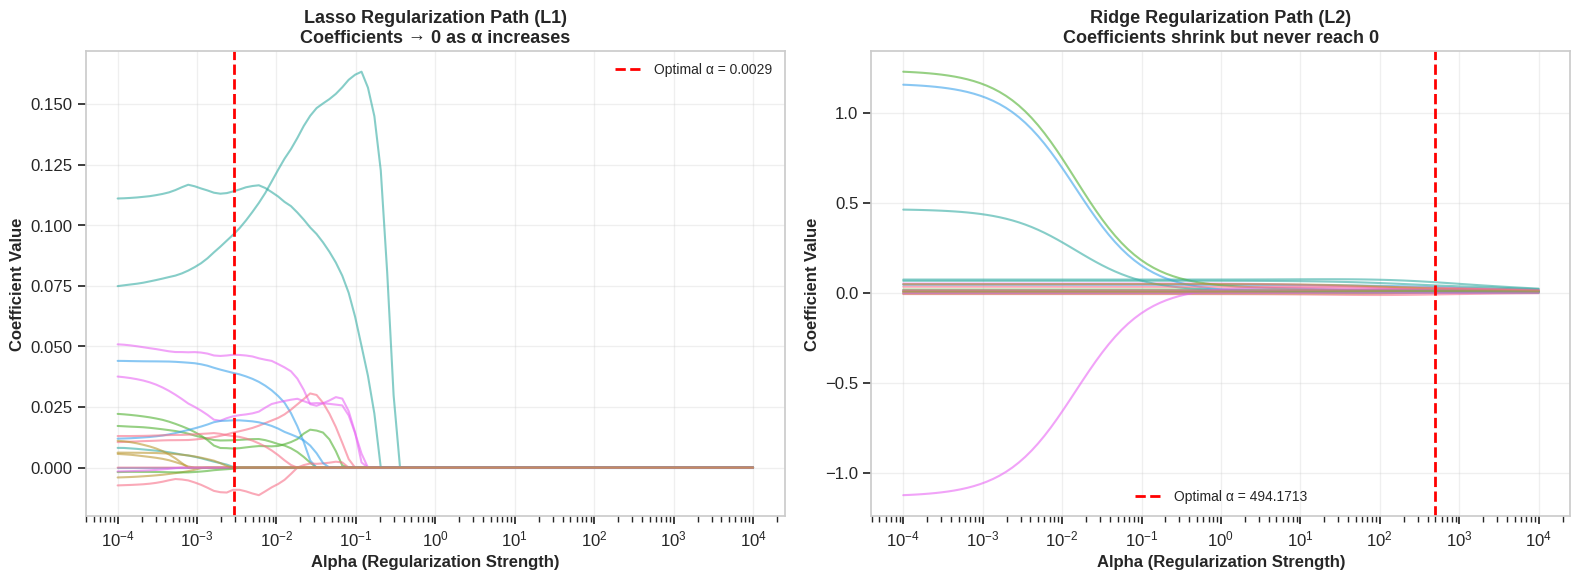


✓ Saved: 16_regularization_paths.png


In [114]:
# Generate regularization paths
alphas = np.logspace(-4, 4, 100)
coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, max_iter=10000)
    ridge_temp = Ridge(alpha=alpha)
    lasso_temp.fit(X_train_scaled, y_train_log)
    ridge_temp.fit(X_train_scaled, y_train_log)
    coefs_lasso.append(lasso_temp.coef_)
    coefs_ridge.append(ridge_temp.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

# Plot regularization paths
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lasso path
ax = axes[0]
for i in range(min(20, coefs_lasso.shape[1])):  # Plot first 20 features
    ax.plot(alphas, coefs_lasso[:, i], alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('Alpha (Regularization Strength)', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Lasso Regularization Path (L1)\nCoefficients → 0 as α increases',
             fontsize=13, fontweight='bold')
ax.axvline(x=lasso_model.alpha, color='red', linestyle='--', linewidth=2,
           label=f'Optimal α = {lasso_model.alpha:.4f}')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Ridge path
ax = axes[1]
for i in range(min(20, coefs_ridge.shape[1])):  # Plot first 20 features
    ax.plot(alphas, coefs_ridge[:, i], alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('Alpha (Regularization Strength)', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Ridge Regularization Path (L2)\nCoefficients shrink but never reach 0',
             fontsize=13, fontweight='bold')
ax.axvline(x=ridge_model.alpha, color='red', linestyle='--', linewidth=2,
           label=f'Optimal α = {ridge_model.alpha:.4f}')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('16_regularization_paths.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 16_regularization_paths.png")

##8.4. FINAL PROJECT SUMMARY

In [116]:
print("\n" + "-"*80)
print("8.4. FINAL PROJECT SUMMARY")
print("-"*80)

print("\n" + "="*80)
print("PROJECT COMPLETE: COMPARATIVE ANALYSIS OF L1 AND L2 REGULARIZATION")
print("="*80)

print("\n--- Dataset Summary ---")
print(f"Total samples: {len(df)}")
print(f"Total features (after encoding): {len(feature_names)}")
print(f"Target variable: SalePrice (${y.min():,.0f} - ${y.max():,.0f})")

print("\n--- Model Performance Summary ---")
results_summary = pd.read_csv('model_comparison_comprehensive.csv')
print(results_summary[['Model', 'Test_RMSE', 'Test_R2', 'Test_MAE']].to_string(index=False))

print("\n--- Key Findings ---")
print("\n1. REGULARIZATION EFFECTIVENESS:")
print(f"   • Ridge (L2): Shrinks all coefficients, retains all {len(feature_names)} features")
print(f"   • Lasso (L1): Eliminates {(~feature_importance_df['Lasso_Selected']).sum()} features")
print(f"                ({(~feature_importance_df['Lasso_Selected']).sum()/len(feature_names)*100:.1f}%)")
print(f"   • Optimal Ridge α: {ridge_model.alpha:.6f}")
print(f"   • Optimal Lasso α: {lasso_model.alpha:.6f}")

print("\n2. MODEL COMPARISON:")
best_model_idx = results_summary['Test_R2'].idxmax()
best_model = results_summary.loc[best_model_idx, 'Model']
best_r2 = results_summary.loc[best_model_idx, 'Test_R2']
best_rmse = results_summary.loc[best_model_idx, 'Test_RMSE']
print(f"   • Best performing model: {best_model}")
print(f"   • Test R²: {best_r2:.4f}")
print(f"   • Test RMSE: ${best_rmse:,.2f}")

print("\n3. FEATURE SELECTION (LASSO):")
print(f"   • Features selected: {feature_importance_df['Lasso_Selected'].sum()}")
print(f"   • Top 3 important features:")
for i, row in top_10_lasso.head(3).iterrows():
    print(f"     - {row['Feature']}: {row['Lasso_Importance']:.4f}")

print("\n4. OVERFITTING ANALYSIS:")
for _, row in results_summary.iterrows():
    overfit = row['Train_R2'] - row['Test_R2']
    status = "✓ Good" if overfit < 0.05 else "⚠ Moderate" if overfit < 0.10 else "✗ High"
    print(f"   • {row['Model']}: {status} (Δ = {overfit:.4f})")

print("\n--- Generated Outputs ---")
outputs = [
    '01-05: EDA visualizations (distribution, correlations)',
    '06-11: Bivariate analysis and relationships',
    '12: Comprehensive model comparison',
    '13: Feature importance analysis',
    '14: Predictions vs actual (all models)',
    '15: Residual analysis',
    '16: Regularization paths (Lasso vs Ridge)',
    'CSV: model_comparison_comprehensive.csv',
    'CSV: feature_importance_comprehensive.csv',
    'CSV: ames_housing_preprocessed.csv'
]
for output in outputs:
    print(f"  ✓ {output}")

print("\n--- Conclusions ---")
print("\n1. L1 (Lasso) successfully performs automatic feature selection")
print(f"   - Eliminates {(~feature_importance_df['Lasso_Selected']).sum()/len(feature_names)*100:.1f}% of features")
print("   - Maintains competitive performance")
print("   - Creates simpler, more interpretable models")

print("\n2. L2 (Ridge) provides robust regularization")
print("   - Shrinks all coefficients toward zero")
print("   - Prevents overfitting without eliminating features")
print("   - Better when all features are potentially relevant")

print("\n3. Both regularization methods improve over baseline OLS")
print("   - Reduced overfitting")
print("   - Better generalization to test data")
print("   - Appropriate for high-dimensional data")

print("\n" + "="*80)
print("ANALYSIS COMPLETE - ALL OBJECTIVES ACHIEVED!")
print("="*80)
print("\nProject Team:")
print("  • Muhammad Anwar Raza (MSDS25002) - Team Lead")
print("  • Fahad Khalid (MSDS25025)")
print("  • Noman Ali (MSDS25054)")
print("\nCourse: CS587 - Statistical and Mathematical Tools for Data Science")
print("Institution: Information Technology University (ITU), Pakistan")
print("="*80)



--------------------------------------------------------------------------------
8.4. FINAL PROJECT SUMMARY
--------------------------------------------------------------------------------

PROJECT COMPLETE: COMPARATIVE ANALYSIS OF L1 AND L2 REGULARIZATION

--- Dataset Summary ---
Total samples: 2930
Total features (after encoding): 246
Target variable: SalePrice ($12,789 - $755,000)

--- Model Performance Summary ---
        Model    Test_RMSE  Test_R2     Test_MAE
          OLS 33399.951980 0.860861 14914.189813
        Ridge 31279.046219 0.877970 15939.345544
Random Forest 27785.690798 0.903706 16190.440006
        Lasso 32609.442254 0.867369 15911.430086

--- Key Findings ---

1. REGULARIZATION EFFECTIVENESS:
   • Ridge (L2): Shrinks all coefficients, retains all 246 features
   • Lasso (L1): Eliminates 132 features
                (53.7%)
   • Optimal Ridge α: 494.171336
   • Optimal Lasso α: 0.002947

2. MODEL COMPARISON:
   • Best performing model: Random Forest
   • Test R²: 0